# Tarea Semanal 5
## Autor: Pedro Guzman


## Consigna 
Comenzaremos con la generación de la siguiente señal:

$$x(n) = a_0 \cdot \text{sen}(\Omega_1 \cdot n) + n_a(n)$$

siendo

$$\Omega_1 = \Omega_0 + f_r \cdot \frac{2\pi}{N}$$

$$\Omega_0 = \frac{\pi}{2}$$

siendo la variable aleatoria definida por la siguiente distribución de probabilidad

$$f_r \sim \mathcal{U}(-2, 2)$$

$$n_a \sim \mathcal{N}(0, \sigma^2)$$

Diseñe los siguientes estimadores, de amplitud $a_1$

$$\hat{a}_1^i = |X_w^i(\Omega_0)| = |\mathcal{F}\{x(n) \cdot w_i(n)\}|$$

para la $i$-ésima realización y la $w$-ésima ventana (ver detalles debajo).

y de frecuencia $\Omega_1$

$$\hat{\Omega}_1^i = \underset{\Omega}{\arg\max}\{|X_w^i(\Omega)|\}$$

para cada una de las ventanas:

- **rectangular** (sin ventana),
- **flattop**
- **blackmanharris**
- **otra** que elija de [scipy.signal.windows](https://docs.scipy.org/doc/scipy/reference/signal.windows.html)

Y siguiendo las siguientes consignas para su experimentación:

- Considere 200 realizaciones (muestras tomadas de $f_r$) de 1000 muestras para cada experimento.
- Parametrice para SNR's de 3 y 10 db (**Ayuda:** calibre $a_0$ para que la potencia de la senoidal sea 1 W).

Se pide:

1) Realizar una tabla por cada SNR, que describa el sesgo y la varianza de cada estimador para cada ventana analizada. Recuerde incluir las ventanas **rectangular** (sin ventana), **flattop** y **blackmanharris** y otras que considere.

**Estimación de Amplitud**

| | $s_a$ | $v_a$ |
|---|---|---|
| Rectangular | | |
| Flat-top | | |
| Blackman | | |
| otras | | |

**Estimación de Frecuencia**

| | $s_a$ | $v_a$ |
|---|---|---|
| Rectangular | | |
| Flat-top | | |
| Blackman | | |
| otras | | |

---

**Ayuda:** Puede calcular experimentalmente el sesgo y la varianza de un estimador:

$$\hat{a}_0 = |X_w^i(\Omega_0)|$$

siendo

$$s_a = E\{\hat{a}_0\} - a_0$$

$$v_a = \text{var}\{\hat{a}_0\} = E\{(\hat{a}_0 - E\{\hat{a}_0\})^2\}$$

y pueden aproximarse cuando consideramos los valores esperados como las medias muestrales

$$E\{\hat{a}_0\} = \hat{\mu}_a = \frac{1}{M} \sum_{j=0}^{M-1} \hat{a}_j$$

$$s_a = \hat{\mu}_a - a_0$$

$$v_a = \frac{1}{M} \sum_{j=0}^{M-1} (\hat{a}_j - \hat{\mu}_a)^2$$

---

**Bonus:**

- 💎 Analice el efecto del zero-padding para el estimador $\hat{\Omega}_1$
- 🤩 Proponga estimadores alternativos para frecuencia y amplitud de la senoidal y repita el experimento.
 



## Solucion Propuesta

In [1]:
#%%
import matplotlib.pyplot as plt
import random
import numpy as np
import scipy.signal as sp
import time
from scipy.fft import fft, ifft
import scipy.signal as signal
from scipy.stats import gaussian_kde


#Funcion del generador de se;ales
def  mi_funcion ( vmax = 1, dc = 0, ff = 1, ph = 0, nn = 100, fs = 50, type_s = 'sine', duty = 0.5, vmed=5e-3, vsigma=0.5e-3) :
    ff=np.array(ff)
    ff=ff.reshape((-1,1)) #Vector fila a Vector columna
    tt = np.arange(start = 0, step = 1/fs, stop = nn/fs)
    if   type_s == 'sine' :
        xx = vmax*np.sin(2*np.pi*ff*tt+ph)+dc
    elif type_s == 'sawtooth' :
        xx = vmax*sp.sawtooth(2*np.pi*ff*tt+ph)+dc
    elif type_s == 'triangle' :
        xx = vmax*sp.sawtooth(2*np.pi*ff*tt+ph,width = 0.5)+dc
    elif type_s == 'invsawtooth' :
        xx = vmax*sp.sawtooth(2*np.pi*ff*tt+ph, width = 0)+dc
    elif type_s == 'square' :
        xx = vmax*sp.square(2*np.pi*ff*tt+ph, duty = duty)+dc
    elif type_s == 'noise' :
        xx = np.random.normal(vmed, vsigma, len(tt))+dc
    else :
        print("Tipo de funcion no existente o incorrecta")
    
    return tt, xx

def Quant(VFS, x, B) :
    
    q = VFS/(2**B)
    SQ = np.round(x/q)*q
    SQ = np.clip(SQ,a_min=-q*(2**(B-1)) , a_max=q*(2**(B-1)-1))
    print(f"Cuanto={q} para Vref={VFS} y cantidad de bits = {B}")
    return SQ

def  mi_generador_ruidoso ( Psine = 1,R = 1 ,SNRdB=10, ff = 1, ph = 0, nn = 100, fs = 50) :
    vmax=np.sqrt(Psine*2*R)
    Pnoise=Psine/(10**(SNRdB/10))
    vsigma=np.sqrt(Pnoise*R)
    tt = np.arange(start = 0, step = 1/fs, stop = nn/fs)
    _, xx_sine = mi_funcion( vmax = vmax, dc = 0, ff = ff, ph= ph, nn = nn, fs = fs, type_s = 'sine')
    _ ,xx_noise = mi_funcion( vmed = 0, vsigma = vsigma, nn = nn, fs = fs, type_s = 'noise')
    xx= xx_sine + xx_noise
    SNR_real = 10 * np.log10(Psine / np.var(xx_noise))
    print(f"SNR real: {SNR_real:.9f} dB")
    return tt, xx, xx_sine , xx_noise

def DFT(x):
    
    N=len(x)
    n = np.arange(N)
    k=n.reshape((N,1)) #Vector fila a Vector columna
    e=np.exp(-2j*np.pi*k*n/N)
    Xk=np.dot(x,e) #Producto Punto.
    
    return Xk 

## Inciso 1, con señal de 10dB

##### Señal y graficos

In [2]:
N=1000
fs   = 2*np.pi #Resolucion espectral normalizada
#fs = 1000
deltaf=fs/N
fr = np.random.uniform(-2,2,200)
ff = fs/4+fr*deltaf
tt2, x10d, _, _ = mi_generador_ruidoso( Psine = 1,R = 1 ,SNRdB=10, ff = ff, ph = 0, nn = N, fs = fs)



SNR real: 10.224456450 dB


In [3]:

win_hamming = signal.windows.hamming(N)
win_flattop = signal.windows.flattop(N)
win_blackman = signal.windows.blackmanharris(N)


norma_hamming = len(win_hamming)/np.sum(win_hamming)
win_hamming = win_hamming * norma_hamming

norma_flattop = len(win_flattop)/np.sum(win_flattop)
win_flattop = win_flattop * norma_flattop

norma_blackman = len(win_blackman)/np.sum(win_blackman)
win_blackman = win_blackman * norma_blackman

In [4]:
freq = np.arange(start = 0, step = deltaf ,stop = fs)
xdft10_rect     = np.fft.fft(x10d,axis=1)
xdft10_hamming  = np.fft.fft(x10d * win_hamming,axis=1)
xdft10_flattop  = np.fft.fft(x10d * win_flattop,axis=1)
xdft10_blackman = np.fft.fft(x10d * win_blackman,axis=1)

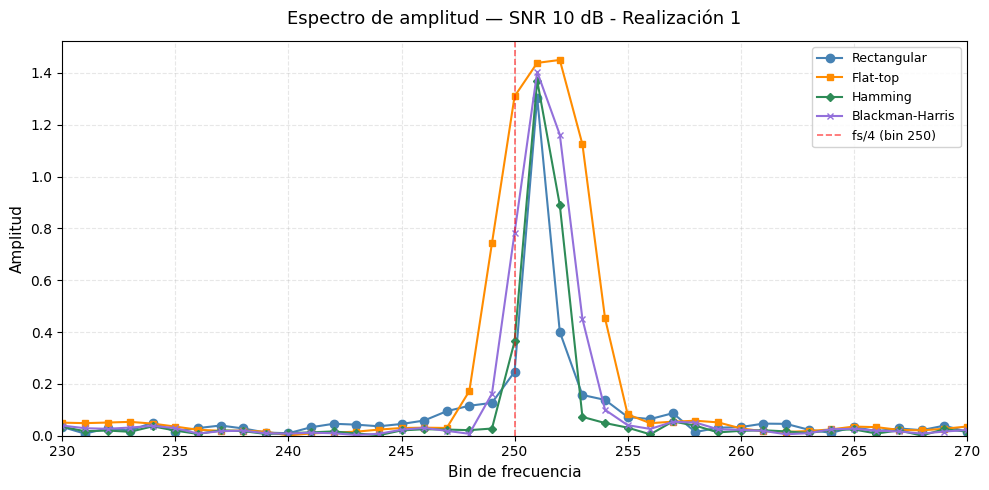

In [5]:
fig, ax = plt.subplots(figsize=(10, 5))

ax.set_title("Espectro de amplitud — SNR 10 dB - Realización 1", fontsize=13, pad=12)
ax.set_xlabel("Bin de frecuencia", fontsize=11)
ax.set_ylabel("Amplitud", fontsize=11)

datos_espectro = [
    (xdft10_rect,     'Rectangular',     'steelblue',   'o',  6),
    (xdft10_flattop,  'Flat-top',        'darkorange',  's',  5),
    (xdft10_hamming,  'Hamming',         'seagreen',    'D',  4),
    (xdft10_blackman, 'Blackman-Harris', 'mediumpurple', 'x', 4),
]

for X, nombre, color, marker, ms in datos_espectro:
    y = 2 * np.abs(X[0]) / len(X[0])
    ax.plot(y, label=nombre, color=color,
            marker=marker, markersize=ms,
            linewidth=1.5, markevery=1)

ax.axvline(N//4, color='red', linestyle='--', linewidth=1.2,
           alpha=0.6, label=f'fs/4 (bin {N//4})')

ax.set_xlim(N//4 - 20, N//4 + 20)
ax.set_ylim(bottom=0)
ax.grid(True, alpha=0.3, linestyle='--')
ax.legend(fontsize=9, framealpha=0.85)
fig.tight_layout()
plt.show()


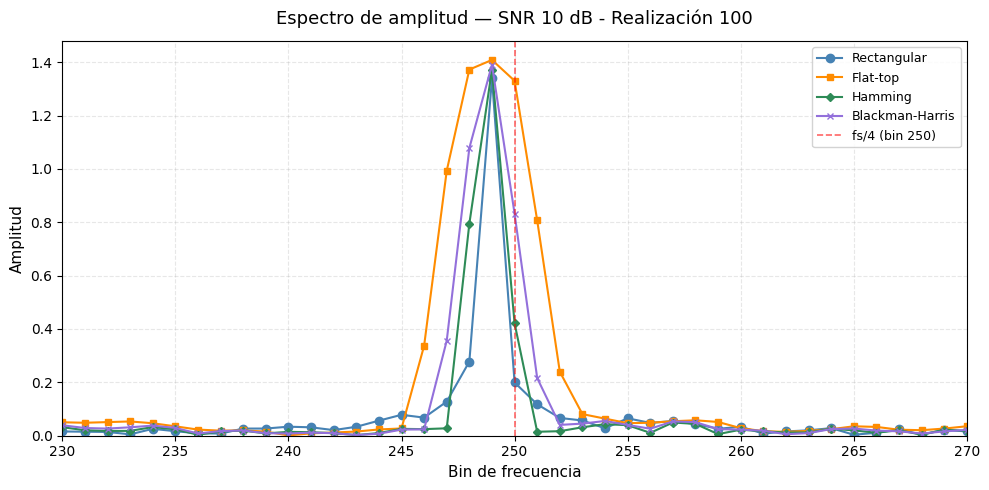

In [6]:
fig, ax = plt.subplots(figsize=(10, 5))

ax.set_title("Espectro de amplitud — SNR 10 dB - Realización 100", fontsize=13, pad=12)
ax.set_xlabel("Bin de frecuencia", fontsize=11)
ax.set_ylabel("Amplitud", fontsize=11)

datos_espectro = [
    (xdft10_rect,     'Rectangular',     'steelblue',   'o',  6),
    (xdft10_flattop,  'Flat-top',        'darkorange',  's',  5),
    (xdft10_hamming,  'Hamming',         'seagreen',    'D',  4),
    (xdft10_blackman, 'Blackman-Harris', 'mediumpurple', 'x', 4),
]

for X, nombre, color, marker, ms in datos_espectro:
    y = 2 * np.abs(X[100]) / len(X[100])
    ax.plot(y, label=nombre, color=color,
            marker=marker, markersize=ms,
            linewidth=1.5, markevery=1)

ax.axvline(N//4, color='red', linestyle='--', linewidth=1.2,
           alpha=0.6, label=f'fs/4 (bin {N//4})')

ax.set_xlim(N//4 - 20, N//4 + 20)
ax.set_ylim(bottom=0)
ax.grid(True, alpha=0.3, linestyle='--')
ax.legend(fontsize=9, framealpha=0.85)
fig.tight_layout()
plt.show()

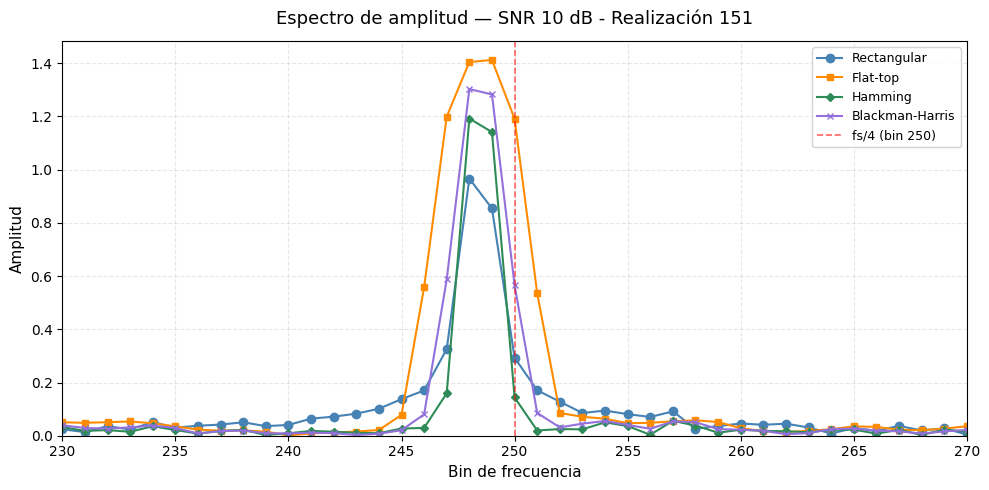

In [7]:
fig, ax = plt.subplots(figsize=(10, 5))

ax.set_title("Espectro de amplitud — SNR 10 dB - Realización 151", fontsize=13, pad=12)
ax.set_xlabel("Bin de frecuencia", fontsize=11)
ax.set_ylabel("Amplitud", fontsize=11)

datos_espectro = [
    (xdft10_rect,     'Rectangular',     'steelblue',   'o',  6),
    (xdft10_flattop,  'Flat-top',        'darkorange',  's',  5),
    (xdft10_hamming,  'Hamming',         'seagreen',    'D',  4),
    (xdft10_blackman, 'Blackman-Harris', 'mediumpurple', 'x', 4),
]

for X, nombre, color, marker, ms in datos_espectro:
    y = 2 * np.abs(X[151]) / len(X[151])
    ax.plot(y, label=nombre, color=color,
            marker=marker, markersize=ms,
            linewidth=1.5, markevery=1)

ax.axvline(N//4, color='red', linestyle='--', linewidth=1.2,
           alpha=0.6, label=f'fs/4 (bin {N//4})')

ax.set_xlim(N//4 - 20, N//4 + 20)
ax.set_ylim(bottom=0)
ax.grid(True, alpha=0.3, linestyle='--')
ax.legend(fontsize=9, framealpha=0.85)
fig.tight_layout()
plt.show()

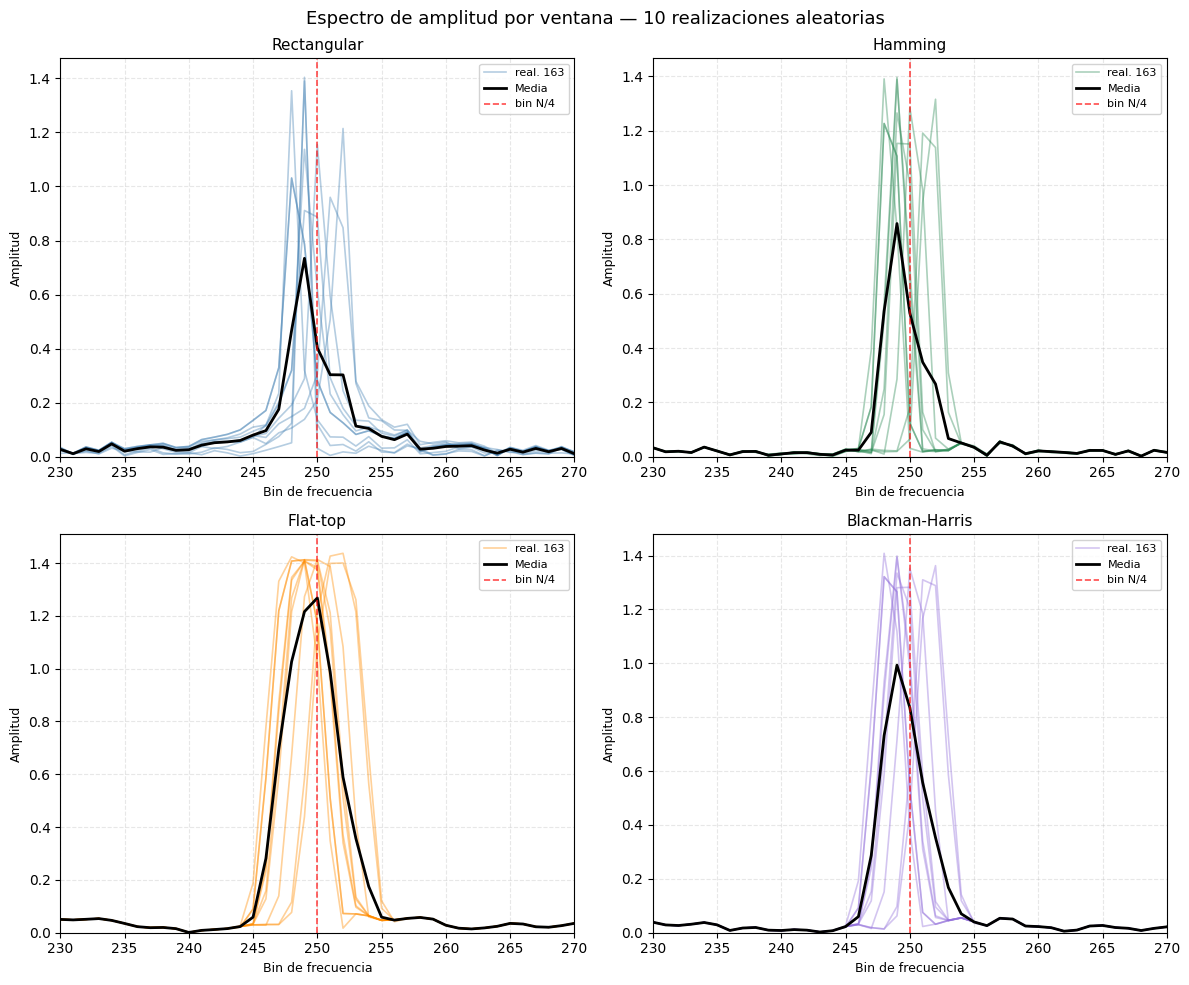

In [8]:
n_realizaciones = 10
indices = random.sample(range(200), n_realizaciones)

ventanas_plot = [
    (xdft10_rect,     'Rectangular',     'steelblue'),
    (xdft10_hamming,  'Hamming',         'seagreen'),
    (xdft10_flattop,  'Flat-top',        'darkorange'),
    (xdft10_blackman, 'Blackman-Harris', 'mediumpurple'),
]

fig, axes = plt.subplots(2, 2, figsize=(12, 10))
fig.suptitle("Espectro de amplitud por ventana — 10 realizaciones aleatorias", fontsize=13)

for ax, (X, nombre, color) in zip(axes.flat, ventanas_plot):

    for i, idx in enumerate(indices):
        y = 2 * np.abs(X[idx]) / len(X[idx])
        ax.plot(y, color=color, linewidth=1.2, alpha=0.4,
                label=f'real. {idx}' if i == 0 else '_')

    # Media de todas las realizaciones
    y_mean = 2 * np.mean(np.abs(X[indices]), axis=0) / X.shape[1]
    ax.plot(y_mean, color='black', linewidth=2, linestyle='-', label='Media')

    ax.axvline(N//4, color='red', linestyle='--', linewidth=1.2, alpha=0.7, label=f'bin N/4')

    ax.set_title(nombre, fontsize=11)
    ax.set_xlabel("Bin de frecuencia", fontsize=9)
    ax.set_ylabel("Amplitud", fontsize=9)
    ax.set_xlim(N//4 - 20, N//4 + 20)
    ax.set_ylim(bottom=0)
    ax.grid(True, alpha=0.3, linestyle='--')
    ax.legend(fontsize=8, framealpha=0.85)

plt.tight_layout()
plt.show()

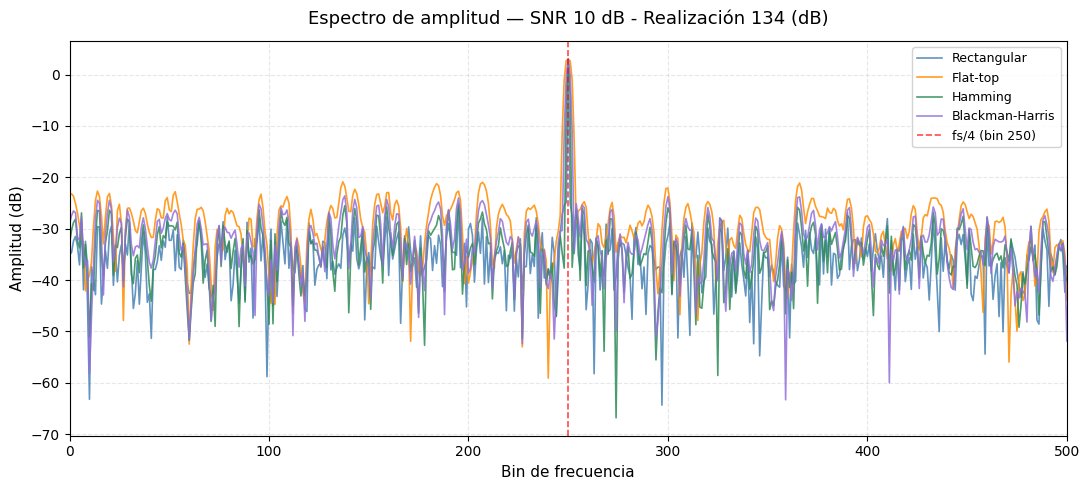

In [9]:
real_idx = np.random.randint(0, 200)

fig, ax = plt.subplots(figsize=(11, 5))
ax.set_title(f"Espectro de amplitud — SNR 10 dB - Realización {real_idx} (dB)", fontsize=13, pad=12)
ax.set_xlabel("Bin de frecuencia", fontsize=11)
ax.set_ylabel("Amplitud (dB)", fontsize=11)

datos_espectro = [
    (xdft10_rect,     'Rectangular',     'steelblue',    'o', 4),
    (xdft10_flattop,  'Flat-top',        'darkorange',   's', 3),
    (xdft10_hamming,  'Hamming',         'seagreen',     'D', 3),
    (xdft10_blackman, 'Blackman-Harris', 'mediumpurple', 'x', 3),
]

for X, nombre, color, marker, ms in datos_espectro:
    y = 2 * np.abs(X[real_idx]) / len(X[real_idx])
    y_db = 20 * np.log10(y + 1e-12)   # +1e-12 para evitar log(0)
    ax.plot(y_db, label=nombre, color=color,
            linewidth=1.2, alpha=0.85)

ax.axvline(N//4, color='red', linestyle='--', linewidth=1.2,
           alpha=0.7, label=f'fs/4 (bin {N//4})')

ax.set_xlim(0, N//2)                  # solo espectro positivo
ax.grid(True, alpha=0.3, linestyle='--')
ax.legend(fontsize=9, framealpha=0.85)
fig.tight_layout()
plt.show()

### Estimación Amplitud

In [10]:
a0 = np.sqrt(2)/2
a_rect = np.abs(xdft10_rect[:, N//4])/N
a_hamming = np.abs(xdft10_hamming[:, N//4])/N
a_flattop = np.abs(xdft10_flattop[:, N//4])/N
a_blackman = np.abs(xdft10_blackman[:, N//4])/N
    
var_rect = np.var(a_rect) 
var_hamming = np.var(a_hamming) 
var_flattop = np.var(a_flattop) 
var_blackman = np.var(a_blackman) 

a_rect_mean = np.mean(a_rect)
a_hamming_mean = np.mean(a_hamming) 
a_flattop_mean = np.mean(a_flattop) 
a_blackman_mean = np.mean(a_blackman) 

Sa_rect =  a0 - a_rect_mean
Sa_hamming = a0 - a_hamming_mean 
Sa_flattop = a0 - a_flattop_mean
Sa_blackman = a0 - a_blackman_mean

sesgo_rel_amp_rect     = (Sa_rect     / a0) * 100
sesgo_rel_amp_hamming  = (Sa_hamming  / a0) * 100
sesgo_rel_amp_flattop  = (Sa_flattop  / a0) * 100
sesgo_rel_amp_blackman = (Sa_blackman / a0) * 100

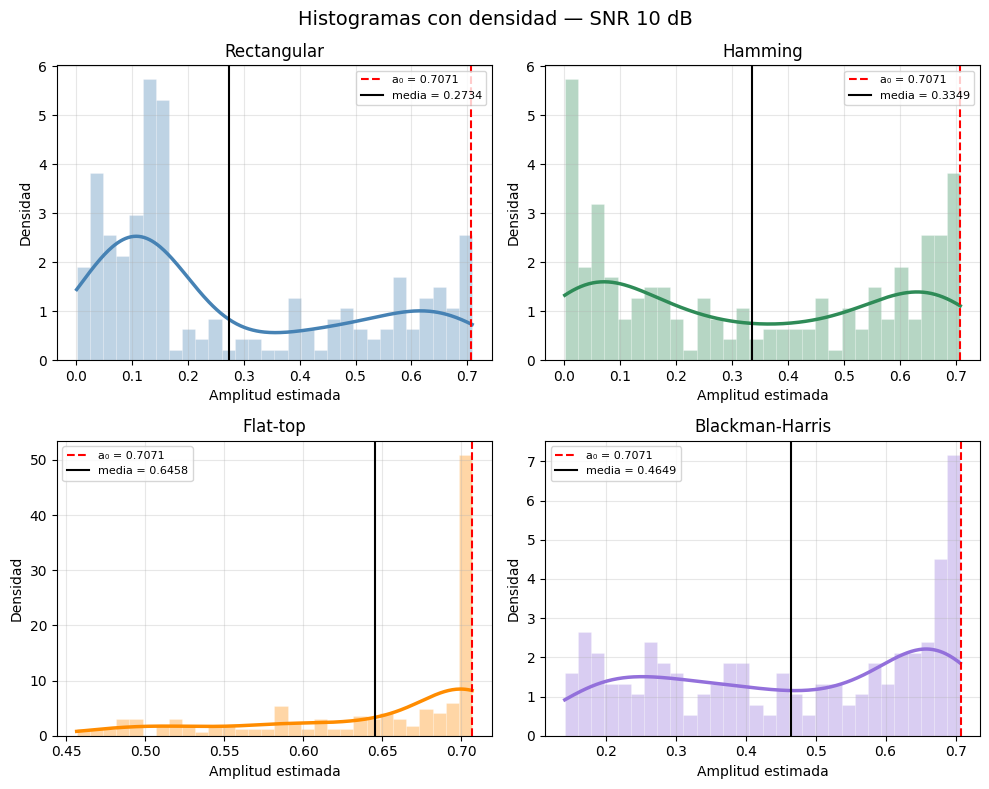

In [11]:

fig, axes = plt.subplots(2, 2, figsize=(10, 8))
fig.suptitle("Histogramas con densidad — SNR 10 dB", fontsize=14)

datos = [
    (a_rect,     'Rectangular',     'steelblue'),
    (a_hamming,  'Hamming',         'seagreen'),
    (a_flattop,  'Flat-top',        'darkorange'),
    (a_blackman, 'Blackman-Harris', 'mediumpurple'),
]

for ax, (a, nombre, color) in zip(axes.flat, datos):
    ax.hist(a, bins=30, color=color, alpha=0.35, edgecolor='white',
            linewidth=0.5, density=True)

    kde = gaussian_kde(a)
    x_kde = np.linspace(a.min(), a.max(), 300)
    ax.plot(x_kde, kde(x_kde), color=color, linewidth=2.5)

    ax.axvline(a0,         color='red',   linestyle='--', linewidth=1.5, label=f'a₀ = {a0:.4f}')
    ax.axvline(np.mean(a), color='black', linestyle='-',  linewidth=1.5, label=f'media = {np.mean(a):.4f}')

    ax.set_title(nombre)
    ax.set_xlabel("Amplitud estimada")
    ax.set_ylabel("Densidad")
    ax.legend(fontsize=8)
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

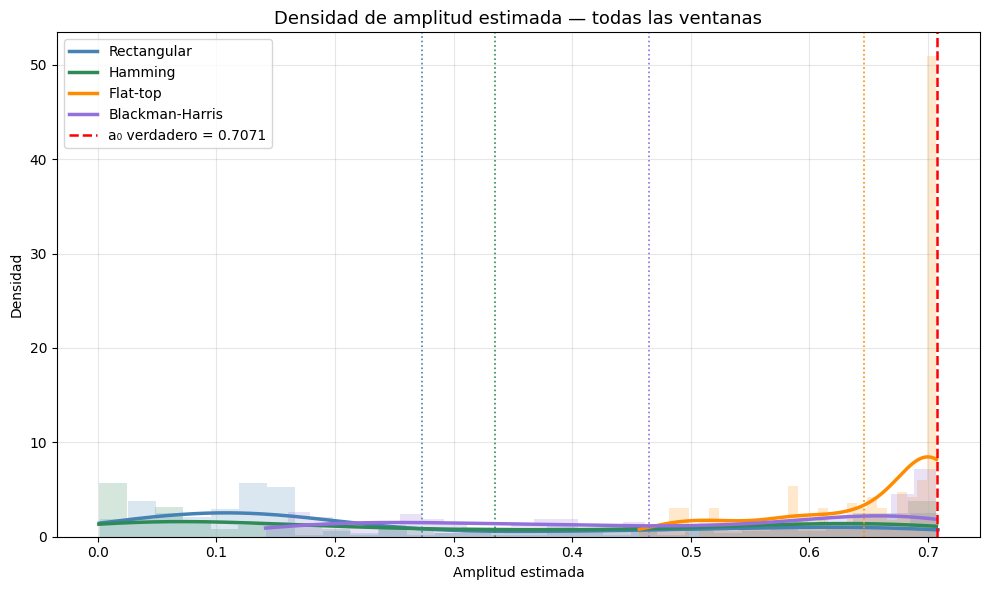

In [12]:
fig, ax = plt.subplots(figsize=(10, 6))
ax.set_title("Densidad de amplitud estimada — todas las ventanas", fontsize=13)

for a, nombre, color in datos:
    ax.hist(a, bins=30, color=color, alpha=0.2, edgecolor='none', density=True)

    kde = gaussian_kde(a)
    x_kde = np.linspace(a.min(), a.max(), 300)
    ax.plot(x_kde, kde(x_kde), color=color, linewidth=2.5, label=nombre)
    ax.axvline(np.mean(a), color=color, linestyle=':', linewidth=1.2)

ax.axvline(a0, color='red', linestyle='--', linewidth=1.8, label=f'a₀ verdadero = {a0:.4f}')

ax.set_xlabel("Amplitud estimada")
ax.set_ylabel("Densidad")
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

### Tabla Final Estimacion Amplitud 10dB

In [13]:

nombres       = ['Rectangular', 'Hamming', 'Flat-top', 'Blackman-Harris']
sesgos_amp     = [Sa_rect,            Sa_hamming,            Sa_flattop,            Sa_blackman]
sesgos_rel_amp = [sesgo_rel_amp_rect, sesgo_rel_amp_hamming, sesgo_rel_amp_flattop, sesgo_rel_amp_blackman]
varianzas_amp  = [var_rect,           var_hamming,           var_flattop,           var_blackman]
medias_amp     = [a_rect_mean,        a_hamming_mean,        a_flattop_mean,        a_blackman_mean]

print("=" * 82)
print(f"{'Ventana':<18} {'Sesgo':>14} {'Sesgo (%)':>11} {'Varianza':>14} {'Media':>14}")
print("=" * 82)
for n, s, sr, v, m in zip(nombres, sesgos_amp, sesgos_rel_amp, varianzas_amp, medias_amp):
    print(f"{n:<18} {s:>+14.6f} {sr:>+10.3f}% {v:>14.3e} {m:>14.6f}")
print("=" * 82)

Ventana                     Sesgo   Sesgo (%)       Varianza          Media
Rectangular             +0.433725    +61.338%      5.349e-02       0.273382
Hamming                 +0.372235    +52.642%      6.590e-02       0.334872
Flat-top                +0.061314     +8.671%      5.589e-03       0.645792
Blackman-Harris         +0.242226    +34.256%      3.613e-02       0.464880


Se puede ver como la estimación de amplitud se hace mejor con la ventana de Flat-Top ya que en la misma es donde tenemos menos Sesgo y Menor Varianza, donde esta ultima es lo mas importante, ya que encontrar un sesgo es facil de corregirlo con un factor de correción.

### Estimación Frecuencia

In [14]:
index_rect     = np.argmax(np.abs(xdft10_rect[:,:N//2]), axis=1)
index_hamming  = np.argmax(np.abs(xdft10_hamming[:,:N//2]), axis=1)
index_flattop  = np.argmax(np.abs(xdft10_flattop[:,:N//2]), axis=1)
index_blackman = np.argmax(np.abs(xdft10_blackman[:,:N//2]), axis=1)

ff_rect     = np.mean(index_rect*deltaf-ff)
ff_hamming  = np.mean(index_hamming*deltaf-ff)
ff_flattop  = np.mean(index_flattop*deltaf-ff)
ff_blackman = np.mean(index_blackman*deltaf-ff)

var_ff_rect = np.var(index_rect*deltaf-ff) 
var_ff_hamming = np.var(index_hamming*deltaf-ff) 
var_ff_flattop = np.var(index_flattop*deltaf-ff) 
var_ff_blackman = np.var(index_blackman*deltaf-ff) 

#sesgo_ff_rect     = np.pi/2 - ff_rect
#sesgo_ff_hamming  = np.pi/2 - ff_hamming
#sesgo_ff_flattop  = np.pi/2 - ff_flattop
#sesgo_ff_blackman = np.pi/2 - ff_blackman

sesgo_ff_rect     =  ff_rect
sesgo_ff_hamming  = ff_hamming
sesgo_ff_flattop  = ff_flattop
sesgo_ff_blackman =  ff_blackman


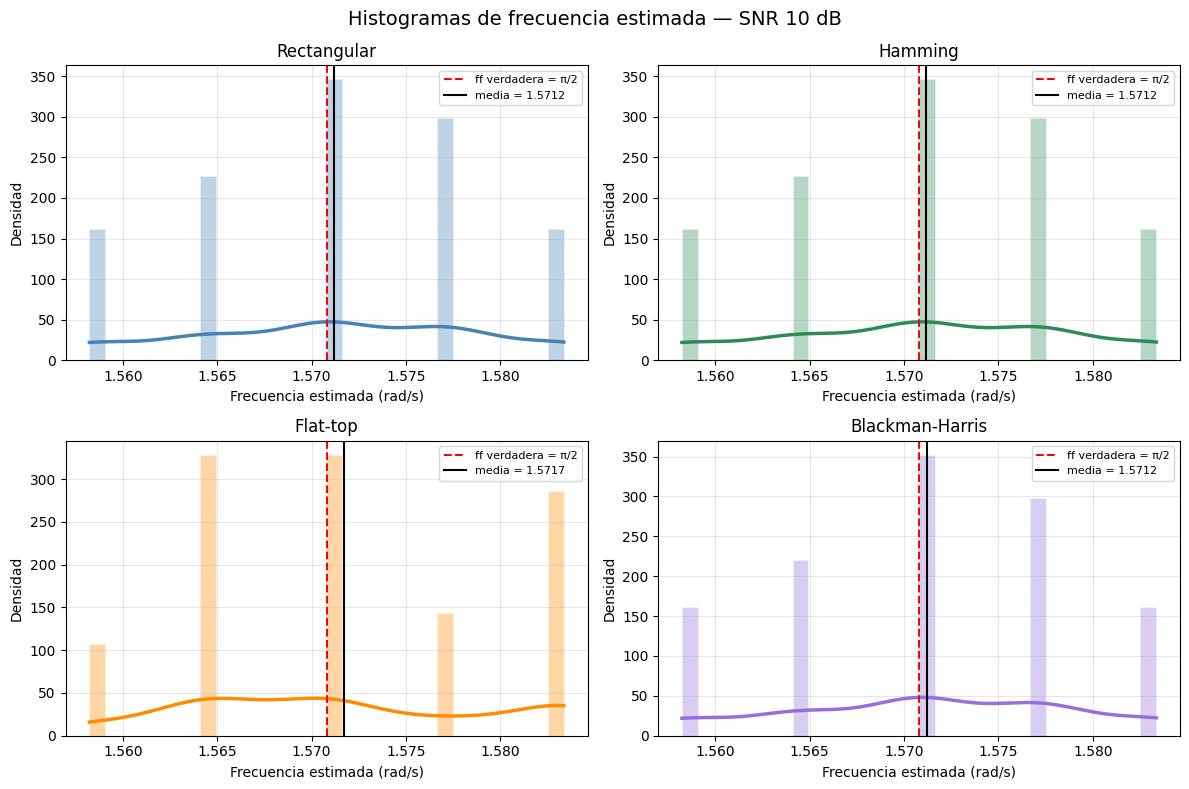

In [15]:
ff_estimadas = [
    (index_rect     * deltaf, 'Rectangular',     'steelblue'),
    (index_hamming  * deltaf, 'Hamming',         'seagreen'),
    (index_flattop  * deltaf, 'Flat-top',        'darkorange'),
    (index_blackman * deltaf, 'Blackman-Harris', 'mediumpurple'),
]

fig, axes = plt.subplots(2, 2, figsize=(12, 8))
fig.suptitle("Histogramas de frecuencia estimada — SNR 10 dB", fontsize=14)

for ax, (ff_est, nombre, color) in zip(axes.flat, ff_estimadas):
    ax.hist(ff_est, bins=30, color=color, alpha=0.35, edgecolor='white',
            linewidth=0.5, density=True)

    kde = gaussian_kde(ff_est)
    x_kde = np.linspace(ff_est.min(), ff_est.max(), 300)
    ax.plot(x_kde, kde(x_kde), color=color, linewidth=2.5)

    ax.axvline(np.pi/2,          color='red',   linestyle='--', linewidth=1.5, label=f'ff verdadera = π/2')
    ax.axvline(np.mean(ff_est),  color='black', linestyle='-',  linewidth=1.5, label=f'media = {np.mean(ff_est):.4f}')

    ax.set_title(nombre)
    ax.set_xlabel("Frecuencia estimada (rad/s)")
    ax.set_ylabel("Densidad")
    ax.legend(fontsize=8)
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

### Tabla Final Estimacion Frecuencia 10dB

In [16]:
nombres       = ['Rectangular', 'Hamming', 'Flat-top', 'Blackman-Harris']
sesgos_ff     = [sesgo_ff_rect,   sesgo_ff_hamming,   sesgo_ff_flattop,   sesgo_ff_blackman]
varianzas_ff  = [var_ff_rect,     var_ff_hamming,     var_ff_flattop,     var_ff_blackman]
medias_ff     = [ff_rect,         ff_hamming,         ff_flattop,         ff_blackman]

print("=" * 82)
print(f"{'Ventana':<18} {'Sesgo':>14} {'Varianza':>14} {'Media':>14}")
print("=" * 82)
for n, s, v, m in zip(nombres, sesgos_ff, varianzas_ff, medias_ff):
    print(f"{n:<18} {s:>+14.8f} {v:>14.4e} {m:>14.8f}")
print("=" * 82)

Ventana                     Sesgo       Varianza          Media
Rectangular           +0.00006246     3.5801e-06     0.00006246
Hamming               +0.00006246     3.5801e-06     0.00006246
Flat-top              +0.00059653     5.2139e-06     0.00059653
Blackman-Harris       +0.00009387     3.5780e-06     0.00009387


## Inciso 1, con señal de 3dB

#### Senal y Graficos

In [17]:
tt1, x3d, _, _ = mi_generador_ruidoso( Psine = 1,R = 1 ,SNRdB=3, ff = ff, ph = 0, nn = N, fs = fs)

SNR real: 3.315918140 dB


In [18]:

win_hamming = signal.windows.hamming(N)
win_flattop = signal.windows.flattop(N)
win_blackman = signal.windows.blackmanharris(N)


norma_hamming = len(win_hamming)/np.sum(win_hamming)
win_hamming = win_hamming * norma_hamming

norma_flattop = len(win_flattop)/np.sum(win_flattop)
win_flattop = win_flattop * norma_flattop

norma_blackman = len(win_blackman)/np.sum(win_blackman)
win_blackman = win_blackman * norma_blackman

In [19]:
freq = np.arange(start = 0, step = deltaf ,stop = fs)
xdft3_rect     = np.fft.fft(x3d,axis=1)
xdft3_hamming  = np.fft.fft(x3d * win_hamming,axis=1)
xdft3_flattop  = np.fft.fft(x3d * win_flattop,axis=1)
xdft3_blackman = np.fft.fft(x3d * win_blackman,axis=1)

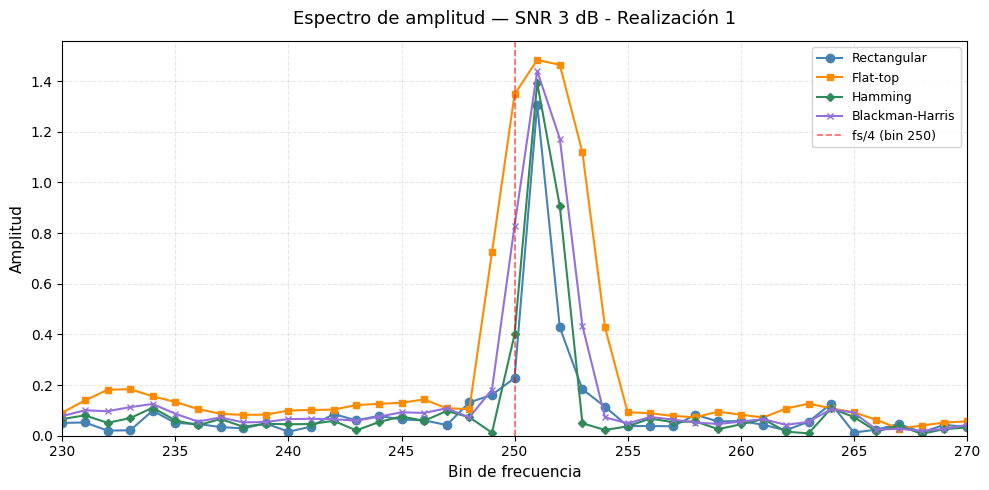

In [20]:
fig, ax = plt.subplots(figsize=(10, 5))

ax.set_title("Espectro de amplitud — SNR 3 dB - Realización 1", fontsize=13, pad=12)
ax.set_xlabel("Bin de frecuencia", fontsize=11)
ax.set_ylabel("Amplitud", fontsize=11)

datos_espectro = [
    (xdft3_rect,     'Rectangular',     'steelblue',   'o',  6),
    (xdft3_flattop,  'Flat-top',        'darkorange',  's',  5),
    (xdft3_hamming,  'Hamming',         'seagreen',    'D',  4),
    (xdft3_blackman, 'Blackman-Harris', 'mediumpurple', 'x', 4),
]

for X, nombre, color, marker, ms in datos_espectro:
    y = 2 * np.abs(X[0]) / len(X[0])
    ax.plot(y, label=nombre, color=color,
            marker=marker, markersize=ms,
            linewidth=1.5, markevery=1)

ax.axvline(N//4, color='red', linestyle='--', linewidth=1.2,
           alpha=0.6, label=f'fs/4 (bin {N//4})')

ax.set_xlim(N//4 - 20, N//4 + 20)
ax.set_ylim(bottom=0)
ax.grid(True, alpha=0.3, linestyle='--')
ax.legend(fontsize=9, framealpha=0.85)
fig.tight_layout()
plt.show()

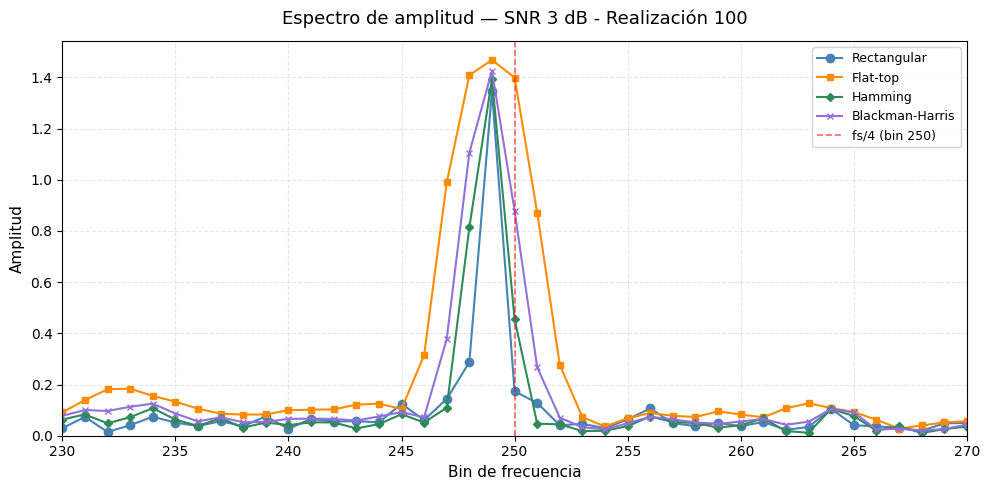

In [21]:
fig, ax = plt.subplots(figsize=(10, 5))

ax.set_title("Espectro de amplitud — SNR 3 dB - Realización 100", fontsize=13, pad=12)
ax.set_xlabel("Bin de frecuencia", fontsize=11)
ax.set_ylabel("Amplitud", fontsize=11)

datos_espectro = [
    (xdft3_rect,     'Rectangular',     'steelblue',   'o',  6),
    (xdft3_flattop,  'Flat-top',        'darkorange',  's',  5),
    (xdft3_hamming,  'Hamming',         'seagreen',    'D',  4),
    (xdft3_blackman, 'Blackman-Harris', 'mediumpurple', 'x', 4),
]

for X, nombre, color, marker, ms in datos_espectro:
    y = 2 * np.abs(X[100]) / len(X[100])
    ax.plot(y, label=nombre, color=color,
            marker=marker, markersize=ms,
            linewidth=1.5, markevery=1)

ax.axvline(N//4, color='red', linestyle='--', linewidth=1.2,
           alpha=0.6, label=f'fs/4 (bin {N//4})')

ax.set_xlim(N//4 - 20, N//4 + 20)
ax.set_ylim(bottom=0)
ax.grid(True, alpha=0.3, linestyle='--')
ax.legend(fontsize=9, framealpha=0.85)
fig.tight_layout()
plt.show()

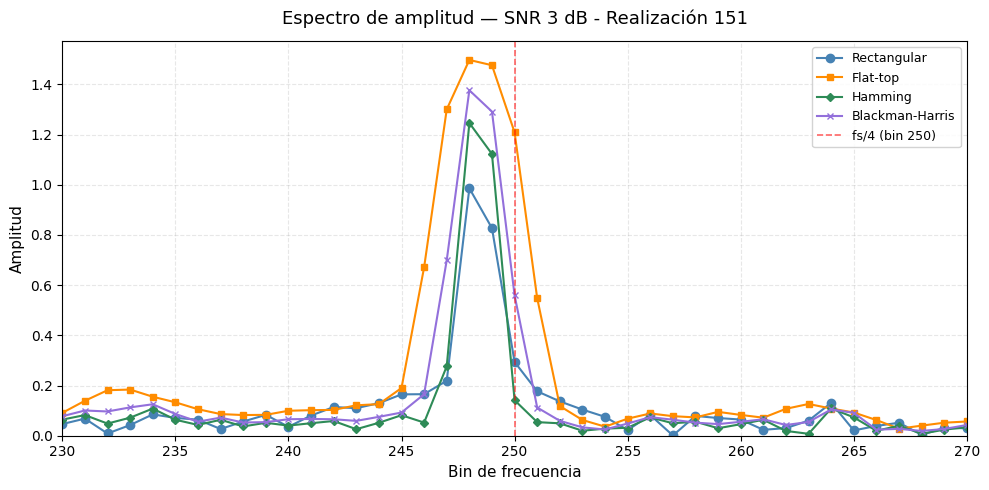

In [22]:
fig, ax = plt.subplots(figsize=(10, 5))

ax.set_title("Espectro de amplitud — SNR 3 dB - Realización 151", fontsize=13, pad=12)
ax.set_xlabel("Bin de frecuencia", fontsize=11)
ax.set_ylabel("Amplitud", fontsize=11)

datos_espectro = [
    (xdft3_rect,     'Rectangular',     'steelblue',   'o',  6),
    (xdft3_flattop,  'Flat-top',        'darkorange',  's',  5),
    (xdft3_hamming,  'Hamming',         'seagreen',    'D',  4),
    (xdft3_blackman, 'Blackman-Harris', 'mediumpurple', 'x', 4),
]

for X, nombre, color, marker, ms in datos_espectro:
    y = 2 * np.abs(X[151]) / len(X[151])
    ax.plot(y, label=nombre, color=color,
            marker=marker, markersize=ms,
            linewidth=1.5, markevery=1)

ax.axvline(N//4, color='red', linestyle='--', linewidth=1.2,
           alpha=0.6, label=f'fs/4 (bin {N//4})')

ax.set_xlim(N//4 - 20, N//4 + 20)
ax.set_ylim(bottom=0)
ax.grid(True, alpha=0.3, linestyle='--')
ax.legend(fontsize=9, framealpha=0.85)
fig.tight_layout()
plt.show()

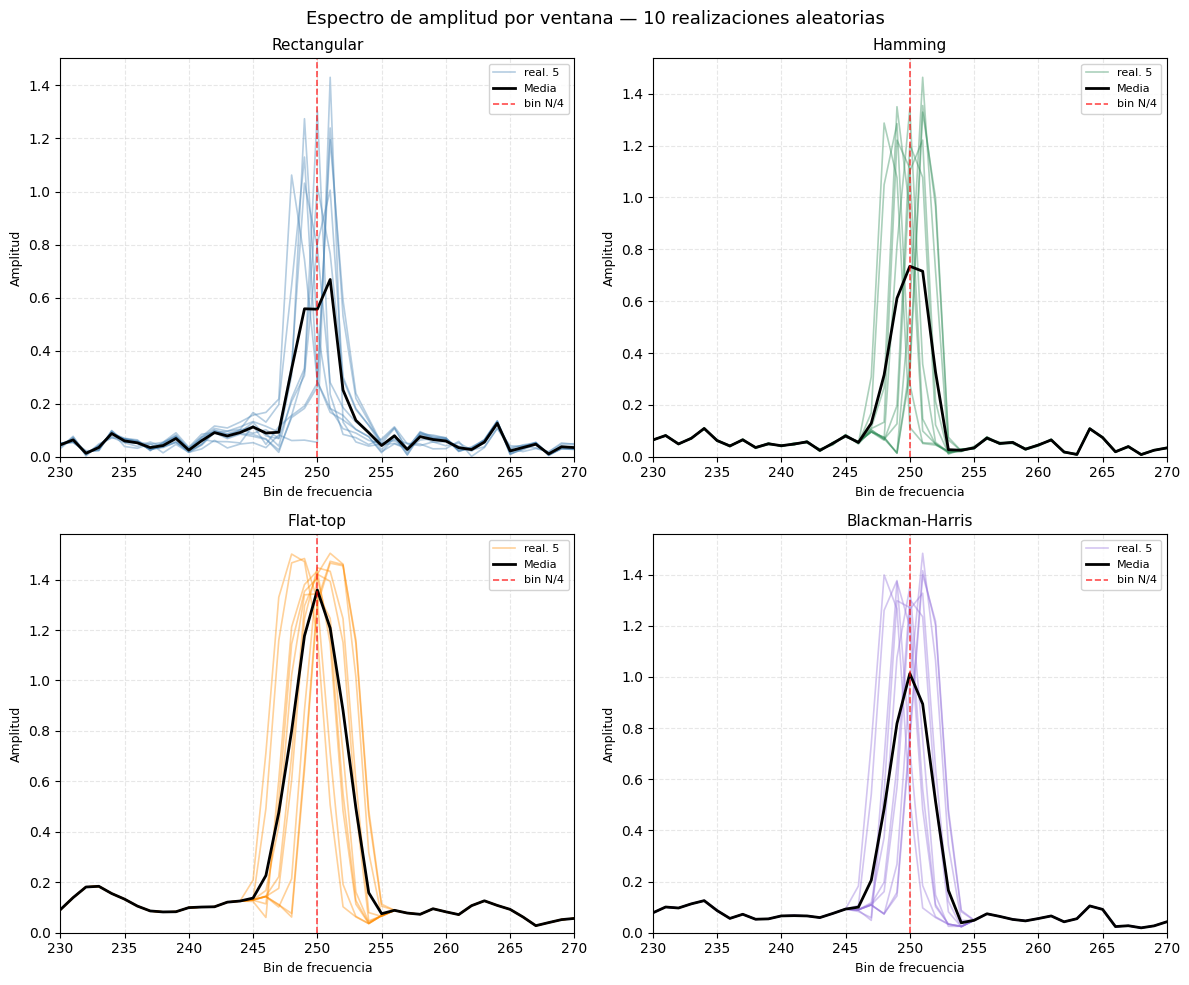

In [23]:
n_realizaciones = 10
indices = random.sample(range(200), n_realizaciones)

ventanas_plot = [
    (xdft3_rect,     'Rectangular',     'steelblue'),
    (xdft3_hamming,  'Hamming',         'seagreen'),
    (xdft3_flattop,  'Flat-top',        'darkorange'),
    (xdft3_blackman, 'Blackman-Harris', 'mediumpurple'),
]

fig, axes = plt.subplots(2, 2, figsize=(12, 10))
fig.suptitle("Espectro de amplitud por ventana — 10 realizaciones aleatorias", fontsize=13)

for ax, (X, nombre, color) in zip(axes.flat, ventanas_plot):

    for i, idx in enumerate(indices):
        y = 2 * np.abs(X[idx]) / len(X[idx])
        ax.plot(y, color=color, linewidth=1.2, alpha=0.4,
                label=f'real. {idx}' if i == 0 else '_')

    # Media de todas las realizaciones
    y_mean = 2 * np.mean(np.abs(X[indices]), axis=0) / X.shape[1]
    ax.plot(y_mean, color='black', linewidth=2, linestyle='-', label='Media')

    ax.axvline(N//4, color='red', linestyle='--', linewidth=1.2, alpha=0.7, label=f'bin N/4')

    ax.set_title(nombre, fontsize=11)
    ax.set_xlabel("Bin de frecuencia", fontsize=9)
    ax.set_ylabel("Amplitud", fontsize=9)
    ax.set_xlim(N//4 - 20, N//4 + 20)
    ax.set_ylim(bottom=0)
    ax.grid(True, alpha=0.3, linestyle='--')
    ax.legend(fontsize=8, framealpha=0.85)

plt.tight_layout()
plt.show()

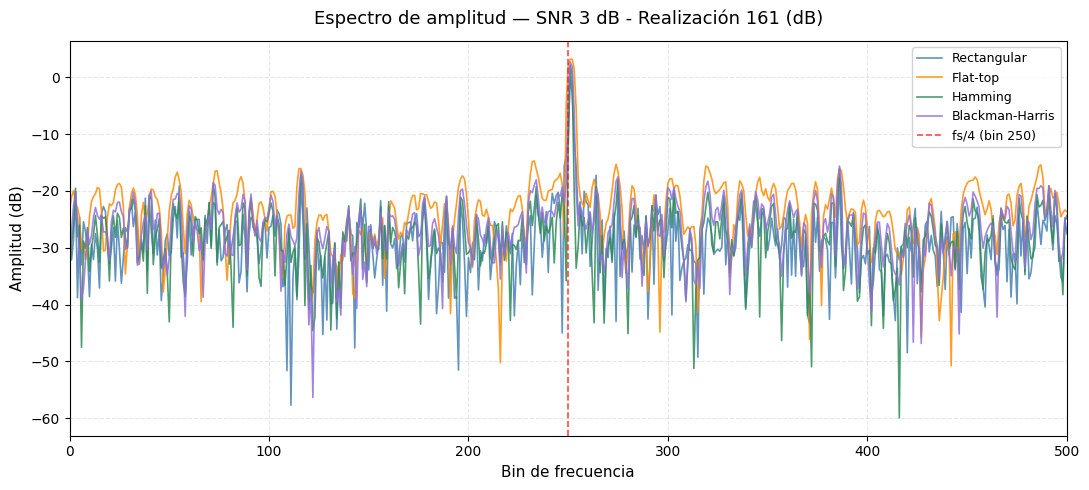

In [24]:
real_idx = np.random.randint(0, 200)

fig, ax = plt.subplots(figsize=(11, 5))
ax.set_title(f"Espectro de amplitud — SNR 3 dB - Realización {real_idx} (dB)", fontsize=13, pad=12)
ax.set_xlabel("Bin de frecuencia", fontsize=11)
ax.set_ylabel("Amplitud (dB)", fontsize=11)

datos_espectro = [
    (xdft3_rect,     'Rectangular',     'steelblue',    'o', 4),
    (xdft3_flattop,  'Flat-top',        'darkorange',   's', 3),
    (xdft3_hamming,  'Hamming',         'seagreen',     'D', 3),
    (xdft3_blackman, 'Blackman-Harris', 'mediumpurple', 'x', 3),
]

for X, nombre, color, marker, ms in datos_espectro:
    y = 2 * np.abs(X[real_idx]) / len(X[real_idx])
    y_db = 20 * np.log10(y + 1e-12)   # +1e-12 para evitar log(0)
    ax.plot(y_db, label=nombre, color=color,
            linewidth=1.2, alpha=0.85)

ax.axvline(N//4, color='red', linestyle='--', linewidth=1.2,
           alpha=0.7, label=f'fs/4 (bin {N//4})')

ax.set_xlim(0, N//2)                  # solo espectro positivo
ax.grid(True, alpha=0.3, linestyle='--')
ax.legend(fontsize=9, framealpha=0.85)
fig.tight_layout()
plt.show()

### Estimación Amplitud

In [25]:
a0 = np.sqrt(2)/2
a_rect = np.abs(xdft3_rect[:, N//4])/N
a_hamming = np.abs(xdft3_hamming[:, N//4])/N
a_flattop = np.abs(xdft3_flattop[:, N//4])/N
a_blackman = np.abs(xdft3_blackman[:, N//4])/N
    
var_rect = np.var(a_rect) 
var_hamming = np.var(a_hamming) 
var_flattop = np.var(a_flattop) 
var_blackman = np.var(a_blackman) 

a_rect_mean = np.mean(a_rect)
a_hamming_mean = np.mean(a_hamming) 
a_flattop_mean = np.mean(a_flattop) 
a_blackman_mean = np.mean(a_blackman) 

Sa_rect =  a0 - a_rect_mean
Sa_hamming = a0 - a_hamming_mean 
Sa_flattop = a0 - a_flattop_mean
Sa_blackman = a0 - a_blackman_mean

sesgo_rel_amp_rect     = (Sa_rect     / a0) * 100
sesgo_rel_amp_hamming  = (Sa_hamming  / a0) * 100
sesgo_rel_amp_flattop  = (Sa_flattop  / a0) * 100
sesgo_rel_amp_blackman = (Sa_blackman / a0) * 100

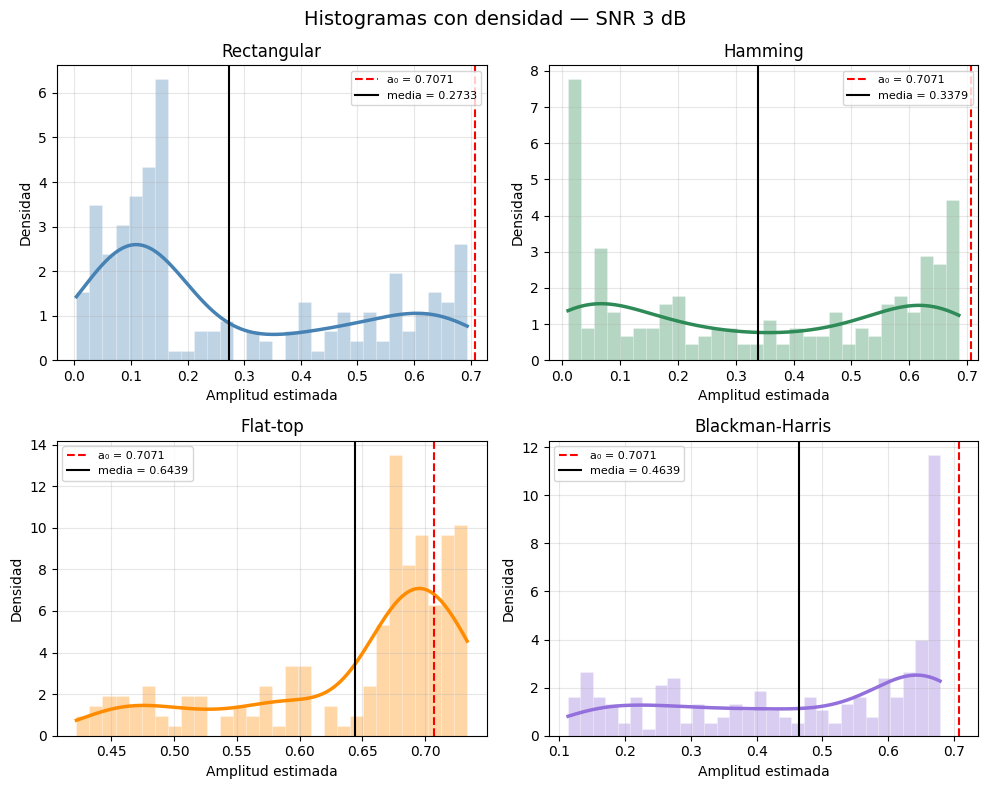

In [26]:

fig, axes = plt.subplots(2, 2, figsize=(10, 8))
fig.suptitle("Histogramas con densidad — SNR 3 dB", fontsize=14)

datos = [
    (a_rect,     'Rectangular',     'steelblue'),
    (a_hamming,  'Hamming',         'seagreen'),
    (a_flattop,  'Flat-top',        'darkorange'),
    (a_blackman, 'Blackman-Harris', 'mediumpurple'),
]

for ax, (a, nombre, color) in zip(axes.flat, datos):
    ax.hist(a, bins=30, color=color, alpha=0.35, edgecolor='white',
            linewidth=0.5, density=True)

    kde = gaussian_kde(a)
    x_kde = np.linspace(a.min(), a.max(), 300)
    ax.plot(x_kde, kde(x_kde), color=color, linewidth=2.5)

    ax.axvline(a0,         color='red',   linestyle='--', linewidth=1.5, label=f'a₀ = {a0:.4f}')
    ax.axvline(np.mean(a), color='black', linestyle='-',  linewidth=1.5, label=f'media = {np.mean(a):.4f}')

    ax.set_title(nombre)
    ax.set_xlabel("Amplitud estimada")
    ax.set_ylabel("Densidad")
    ax.legend(fontsize=8)
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

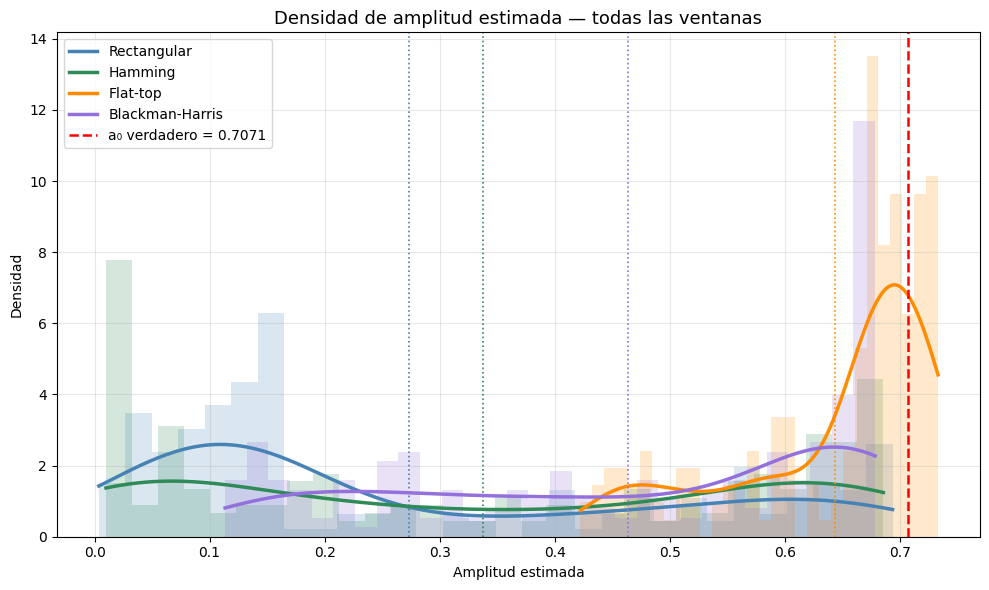

In [27]:
fig, ax = plt.subplots(figsize=(10, 6))
ax.set_title("Densidad de amplitud estimada — todas las ventanas", fontsize=13)

for a, nombre, color in datos:
    ax.hist(a, bins=30, color=color, alpha=0.2, edgecolor='none', density=True)

    kde = gaussian_kde(a)
    x_kde = np.linspace(a.min(), a.max(), 300)
    ax.plot(x_kde, kde(x_kde), color=color, linewidth=2.5, label=nombre)
    ax.axvline(np.mean(a), color=color, linestyle=':', linewidth=1.2)

ax.axvline(a0, color='red', linestyle='--', linewidth=1.8, label=f'a₀ verdadero = {a0:.4f}')

ax.set_xlabel("Amplitud estimada")
ax.set_ylabel("Densidad")
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

### Tabla Final Estimacion Amplitud 3dB

In [28]:

nombres   = ['Rectangular', 'Hamming', 'Flat-top', 'Blackman-Harris']
# Amplitud
sesgos_amp     = [Sa_rect,            Sa_hamming,            Sa_flattop,            Sa_blackman]
sesgos_rel_amp = [sesgo_rel_amp_rect, sesgo_rel_amp_hamming, sesgo_rel_amp_flattop, sesgo_rel_amp_blackman]
varianzas_amp  = [var_rect,           var_hamming,           var_flattop,           var_blackman]
medias_amp     = [a_rect_mean,        a_hamming_mean,        a_flattop_mean,        a_blackman_mean]

print("=" * 82)
print(f"{'Ventana':<18} {'Sesgo':>14} {'Sesgo (%)':>11} {'Varianza':>14} {'Media':>14}")
print("=" * 82)
for n, s, sr, v, m in zip(nombres, sesgos_amp, sesgos_rel_amp, varianzas_amp, medias_amp):
    print(f"{n:<18} {s:>+14.6f} {sr:>+10.3f}% {v:>14.3e} {m:>14.6f}")
print("=" * 82)


Ventana                     Sesgo   Sesgo (%)       Varianza          Media
Rectangular             +0.433834    +61.353%      5.105e-02       0.273273
Hamming                 +0.369223    +52.216%      6.300e-02       0.337884
Flat-top                +0.063173     +8.934%      7.533e-03       0.643934
Blackman-Harris         +0.243172    +34.390%      3.694e-02       0.463934


### Estimacion Frecuencia

In [29]:
index_rect     = np.argmax(np.abs(xdft3_rect[:,:N//2]), axis=1)
index_hamming  = np.argmax(np.abs(xdft3_hamming[:,:N//2]), axis=1)
index_flattop  = np.argmax(np.abs(xdft3_flattop[:,:N//2]), axis=1)
index_blackman = np.argmax(np.abs(xdft3_blackman[:,:N//2]), axis=1)


ff_rect     = np.mean(index_rect*deltaf-ff)
ff_hamming  = np.mean(index_hamming*deltaf-ff)
ff_flattop  = np.mean(index_flattop*deltaf-ff)
ff_blackman = np.mean(index_blackman*deltaf-ff)

var_ff_rect = np.var(index_rect*deltaf-ff) 
var_ff_hamming = np.var(index_hamming*deltaf-ff) 
var_ff_flattop = np.var(index_flattop*deltaf-ff) 
var_ff_blackman = np.var(index_blackman*deltaf-ff) 

#sesgo_ff_rect     = np.pi/2 - ff_rect
#sesgo_ff_hamming  = np.pi/2 - ff_hamming
#sesgo_ff_flattop  = np.pi/2 - ff_flattop
#sesgo_ff_blackman = np.pi/2 - ff_blackman

sesgo_ff_rect     =  ff_rect
sesgo_ff_hamming  = ff_hamming
sesgo_ff_flattop  = ff_flattop
sesgo_ff_blackman =  ff_blackman

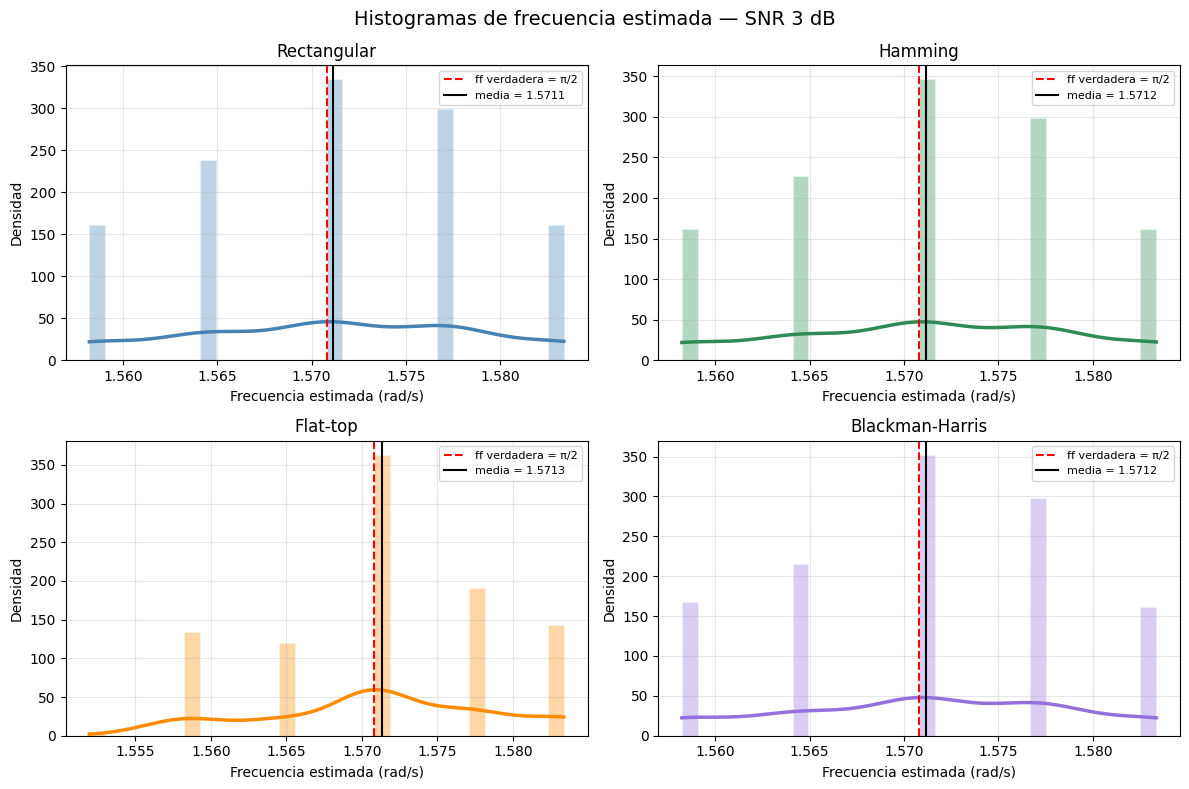

In [30]:
ff_estimadas = [
    (index_rect     * deltaf, 'Rectangular',     'steelblue'),
    (index_hamming  * deltaf, 'Hamming',         'seagreen'),
    (index_flattop  * deltaf, 'Flat-top',        'darkorange'),
    (index_blackman * deltaf, 'Blackman-Harris', 'mediumpurple'),
]

fig, axes = plt.subplots(2, 2, figsize=(12, 8))
fig.suptitle("Histogramas de frecuencia estimada — SNR 3 dB", fontsize=14)

for ax, (ff_est, nombre, color) in zip(axes.flat, ff_estimadas):
    ax.hist(ff_est, bins=30, color=color, alpha=0.35, edgecolor='white',
            linewidth=0.5, density=True)

    kde = gaussian_kde(ff_est)
    x_kde = np.linspace(ff_est.min(), ff_est.max(), 300)
    ax.plot(x_kde, kde(x_kde), color=color, linewidth=2.5)

    ax.axvline(np.pi/2,          color='red',   linestyle='--', linewidth=1.5, label=f'ff verdadera = π/2')
    ax.axvline(np.mean(ff_est),  color='black', linestyle='-',  linewidth=1.5, label=f'media = {np.mean(ff_est):.4f}')

    ax.set_title(nombre)
    ax.set_xlabel("Frecuencia estimada (rad/s)")
    ax.set_ylabel("Densidad")
    ax.legend(fontsize=8)
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

### Tabla Final Estimacion Frecuencia 3dB

In [31]:
nombres       = ['Rectangular', 'Hamming', 'Flat-top', 'Blackman-Harris']
sesgos_ff     = [sesgo_ff_rect,   sesgo_ff_hamming,   sesgo_ff_flattop,   sesgo_ff_blackman]
varianzas_ff  = [var_ff_rect,     var_ff_hamming,     var_ff_flattop,     var_ff_blackman]
medias_ff     = [ff_rect,         ff_hamming,         ff_flattop,         ff_blackman]

print("=" * 82)
print(f"{'Ventana':<18} {'Sesgo':>14} {'Varianza':>14} {'Media':>14}")
print("=" * 82)
for n, s, v, m in zip(nombres, sesgos_ff, varianzas_ff, medias_ff):
    print(f"{n:<18} {s:>+14.8f} {v:>14.4e} {m:>14.8f}")
print("=" * 82)

Ventana                     Sesgo       Varianza          Media
Rectangular           -0.00000038     3.5866e-06    -0.00000038
Hamming               +0.00006246     3.5801e-06     0.00006246
Flat-top              +0.00018812     6.8059e-06     0.00018812
Blackman-Harris       +0.00006246     3.5982e-06     0.00006246


## BONUS 1

#### Bonus 10dB

In [32]:
Zp=100
Nzp= Zp*N
deltafzp = fs/(Nzp)
#print(deltaf)

In [33]:
xdft10_rect_p     = np.fft.fft(x10d,axis=1,n=Nzp)
xdft10_hamming_p    = np.fft.fft(x10d * win_hamming,axis=1,n=Nzp)
xdft10_flattop_p    = np.fft.fft(x10d * win_flattop,axis=1,n=Nzp)
xdft10_blackman_p   = np.fft.fft(x10d * win_blackman,axis=1,n=Nzp)

In [34]:
index_rect     = np.argmax(np.abs(xdft10_rect_p[:,:(Nzp)//2]), axis=1)
index_hamming  = np.argmax(np.abs(xdft10_hamming_p[:,:(Nzp)//2]), axis=1)
index_flattop  = np.argmax(np.abs(xdft10_flattop_p[:,:(Nzp)//2]), axis=1)
index_blackman = np.argmax(np.abs(xdft10_blackman_p[:,:(Nzp)//2]), axis=1)

ff_rect     = np.mean(index_rect*deltafzp-ff)
ff_hamming  = np.mean(index_hamming*deltafzp-ff)
ff_flattop  = np.mean(index_flattop*deltafzp-ff)
ff_blackman = np.mean(index_blackman*deltafzp-ff)

var_ff_rect = np.var(index_rect*deltafzp-ff) 
var_ff_hamming = np.var(index_hamming*deltafzp-ff) 
var_ff_flattop = np.var(index_flattop*deltafzp-ff) 
var_ff_blackman = np.var(index_blackman*deltafzp-ff) 

#sesgo_ff_rect     = np.pi/2 - ff_rect
#sesgo_ff_hamming  = np.pi/2 - ff_hamming
#sesgo_ff_flattop  = np.pi/2 - ff_flattop
#sesgo_ff_blackman = np.pi/2 - ff_blackman

sesgo_ff_rect     =  ff_rect
sesgo_ff_hamming  = ff_hamming
sesgo_ff_flattop  = ff_flattop
sesgo_ff_blackman =  ff_blackman


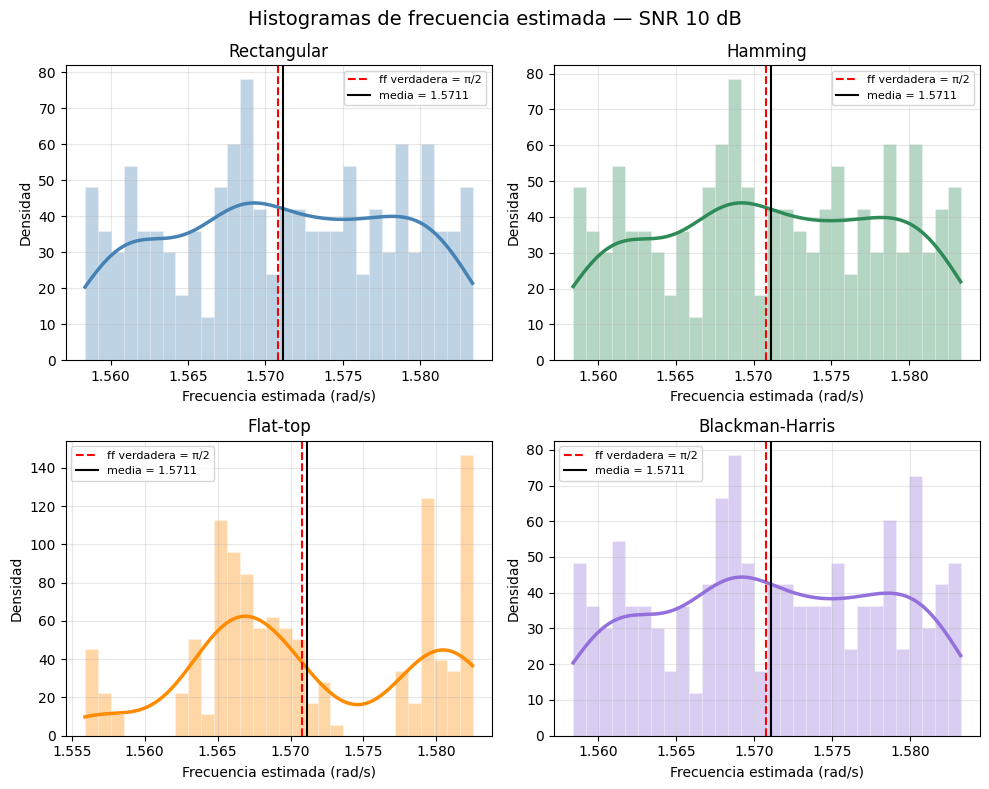

In [35]:
ff_estimadas = [
    (index_rect     * deltafzp, 'Rectangular',     'steelblue'),
    (index_hamming  * deltafzp, 'Hamming',         'seagreen'),
    (index_flattop  * deltafzp, 'Flat-top',        'darkorange'),
    (index_blackman * deltafzp, 'Blackman-Harris', 'mediumpurple'),
]

fig, axes = plt.subplots(2, 2, figsize=(10, 8))
fig.suptitle("Histogramas de frecuencia estimada — SNR 10 dB", fontsize=14)

for ax, (ff_est, nombre, color) in zip(axes.flat, ff_estimadas):
    ax.hist(ff_est, bins=30, color=color, alpha=0.35, edgecolor='white',
            linewidth=0.5, density=True)

    kde = gaussian_kde(ff_est)
    x_kde = np.linspace(ff_est.min(), ff_est.max(), 300)
    ax.plot(x_kde, kde(x_kde), color=color, linewidth=2.5)

    ax.axvline(np.pi/2,          color='red',   linestyle='--', linewidth=1.5, label=f'ff verdadera = π/2')
    ax.axvline(np.mean(ff_est),  color='black', linestyle='-',  linewidth=1.5, label=f'media = {np.mean(ff_est):.4f}')

    ax.set_title(nombre)
    ax.set_xlabel("Frecuencia estimada (rad/s)")
    ax.set_ylabel("Densidad")
    ax.legend(fontsize=8)
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [36]:

nombres       = ['Rectangular', 'Hamming', 'Flat-top', 'Blackman-Harris']
sesgos_ff     = [sesgo_ff_rect,   sesgo_ff_hamming,   sesgo_ff_flattop,   sesgo_ff_blackman]
varianzas_ff  = [var_ff_rect,     var_ff_hamming,     var_ff_flattop,     var_ff_blackman]
medias_ff     = [ff_rect,         ff_hamming,         ff_flattop,         ff_blackman]

print("=" * 82)
print(f"{'Ventana':<18} {'Sesgo':>14} {'Varianza':>14} {'Media':>14}")
print("=" * 82)
for n, s, v, m in zip(nombres, sesgos_ff, varianzas_ff, medias_ff):
    print(f"{n:<18} {s:>+14.8f} {v:>14.4e} {m:>14.8f}")
print("=" * 82)

Ventana                     Sesgo       Varianza          Media
Rectangular           +0.00000245     7.1800e-10     0.00000245
Hamming               +0.00000779     1.2138e-09     0.00000779
Flat-top              -0.00001074     6.9524e-06    -0.00001074
Blackman-Harris       +0.00000936     4.3431e-09     0.00000936


#### Bonus 3dB

In [37]:
Nzp= Zp*N
deltafzp = fs/(Nzp)

In [38]:
xdft3_rect_p     = np.fft.fft(x3d,axis=1,n=Nzp)
xdft3_hamming_p  = np.fft.fft(x3d * win_hamming,axis=1,n=Nzp)
xdft3_flattop_p  = np.fft.fft(x3d * win_flattop,axis=1,n=Nzp)
xdft3_blackman_p = np.fft.fft(x3d * win_blackman,axis=1,n=Nzp)

In [39]:
index_rect     = np.argmax(np.abs(xdft3_rect_p[:,:(Nzp)//2]), axis=1)
index_hamming  = np.argmax(np.abs(xdft3_hamming_p[:,:(Nzp)//2]), axis=1)
index_flattop  = np.argmax(np.abs(xdft3_flattop_p[:,:(Nzp)//2]), axis=1)
index_blackman = np.argmax(np.abs(xdft3_blackman_p[:,:(Nzp)//2]), axis=1)

ff_rect     = np.mean(index_rect*deltafzp-ff)
ff_hamming  = np.mean(index_hamming*deltafzp-ff)
ff_flattop  = np.mean(index_flattop*deltafzp-ff)
ff_blackman = np.mean(index_blackman*deltafzp-ff)

var_ff_rect = np.var(index_rect*deltafzp-ff) 
var_ff_hamming = np.var(index_hamming*deltafzp-ff) 
var_ff_flattop = np.var(index_flattop*deltafzp-ff) 
var_ff_blackman = np.var(index_blackman*deltafzp-ff) 

#sesgo_ff_rect     = np.pi/2 - ff_rect
#sesgo_ff_hamming  = np.pi/2 - ff_hamming
#sesgo_ff_flattop  = np.pi/2 - ff_flattop
#sesgo_ff_blackman = np.pi/2 - ff_blackman

sesgo_ff_rect     =  ff_rect
sesgo_ff_hamming  = ff_hamming
sesgo_ff_flattop  = ff_flattop
sesgo_ff_blackman =  ff_blackman

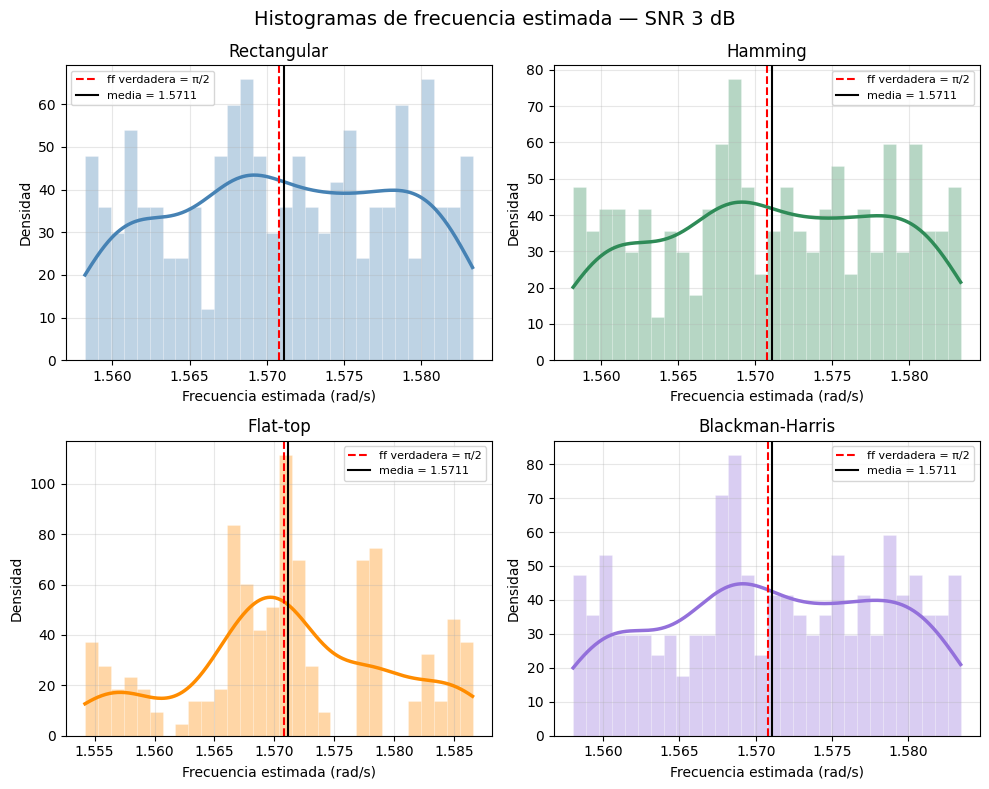

In [40]:
ff_estimadas = [
    (index_rect     * deltafzp, 'Rectangular',     'steelblue'),
    (index_hamming  * deltafzp, 'Hamming',         'seagreen'),
    (index_flattop  * deltafzp, 'Flat-top',        'darkorange'),
    (index_blackman * deltafzp, 'Blackman-Harris', 'mediumpurple'),
]

fig, axes = plt.subplots(2, 2, figsize=(10, 8))
fig.suptitle("Histogramas de frecuencia estimada — SNR 3 dB", fontsize=14)

for ax, (ff_est, nombre, color) in zip(axes.flat, ff_estimadas):
    ax.hist(ff_est, bins=30, color=color, alpha=0.35, edgecolor='white',
            linewidth=0.5, density=True)

    kde = gaussian_kde(ff_est)
    x_kde = np.linspace(ff_est.min(), ff_est.max(), 300)
    ax.plot(x_kde, kde(x_kde), color=color, linewidth=2.5)

    ax.axvline(np.pi/2,          color='red',   linestyle='--', linewidth=1.5, label=f'ff verdadera = π/2')
    ax.axvline(np.mean(ff_est),  color='black', linestyle='-',  linewidth=1.5, label=f'media = {np.mean(ff_est):.4f}')

    ax.set_title(nombre)
    ax.set_xlabel("Frecuencia estimada (rad/s)")
    ax.set_ylabel("Densidad")
    ax.legend(fontsize=8)
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [41]:

nombres       = ['Rectangular', 'Hamming', 'Flat-top', 'Blackman-Harris']
sesgos_ff     = [sesgo_ff_rect,   sesgo_ff_hamming,   sesgo_ff_flattop,   sesgo_ff_blackman]
varianzas_ff  = [var_ff_rect,     var_ff_hamming,     var_ff_flattop,     var_ff_blackman]
medias_ff     = [ff_rect,         ff_hamming,         ff_flattop,         ff_blackman]

print("=" * 82)
print(f"{'Ventana':<18} {'Sesgo':>14} {'Varianza':>14} {'Media':>14}")
print("=" * 82)
for n, s, v, m in zip(nombres, sesgos_ff, varianzas_ff, medias_ff):
    print(f"{n:<18} {s:>+14.8f} {v:>14.4e} {m:>14.8f}")
print("=" * 82)

Ventana                     Sesgo       Varianza          Media
Rectangular           -0.00003242     1.9947e-09    -0.00003242
Hamming               -0.00002708     9.1085e-09    -0.00002708
Flat-top              -0.00000949     9.5991e-06    -0.00000949
Blackman-Harris       -0.00003493     3.3414e-08    -0.00003493


## BONUS 2

Para el estimador de Amplitud voy a usar de maxima amplitud como estimador.

#### Estimador de Amplitud 10dB

In [42]:
a0 = np.sqrt(2)/2
a_rect = np.max(np.abs(xdft10_rect[:,:N//2])/N, axis=1)
a_hamming = np.max(np.abs(xdft10_hamming[:,:N//2])/N, axis=1)
a_flattop = np.max(np.abs(xdft10_flattop[:,:N//2])/N, axis=1)
a_blackman = np.max(np.abs(xdft10_blackman[:,:N//2])/N, axis=1)
    
var_rect = np.var(a_rect) 
var_hamming = np.var(a_hamming) 
var_flattop = np.var(a_flattop) 
var_blackman = np.var(a_blackman) 

a_rect_mean = np.mean(a_rect)
a_hamming_mean = np.mean(a_hamming) 
a_flattop_mean = np.mean(a_flattop) 
a_blackman_mean = np.mean(a_blackman) 

Sa_rect =  a0 - a_rect_mean
Sa_hamming = a0 - a_hamming_mean 
Sa_flattop = a0 - a_flattop_mean
Sa_blackman = a0 - a_blackman_mean

sesgo_rel_amp_rect     = (Sa_rect     / a0) * 100
sesgo_rel_amp_hamming  = (Sa_hamming  / a0) * 100
sesgo_rel_amp_flattop  = (Sa_flattop  / a0) * 100
sesgo_rel_amp_blackman = (Sa_blackman / a0) * 100

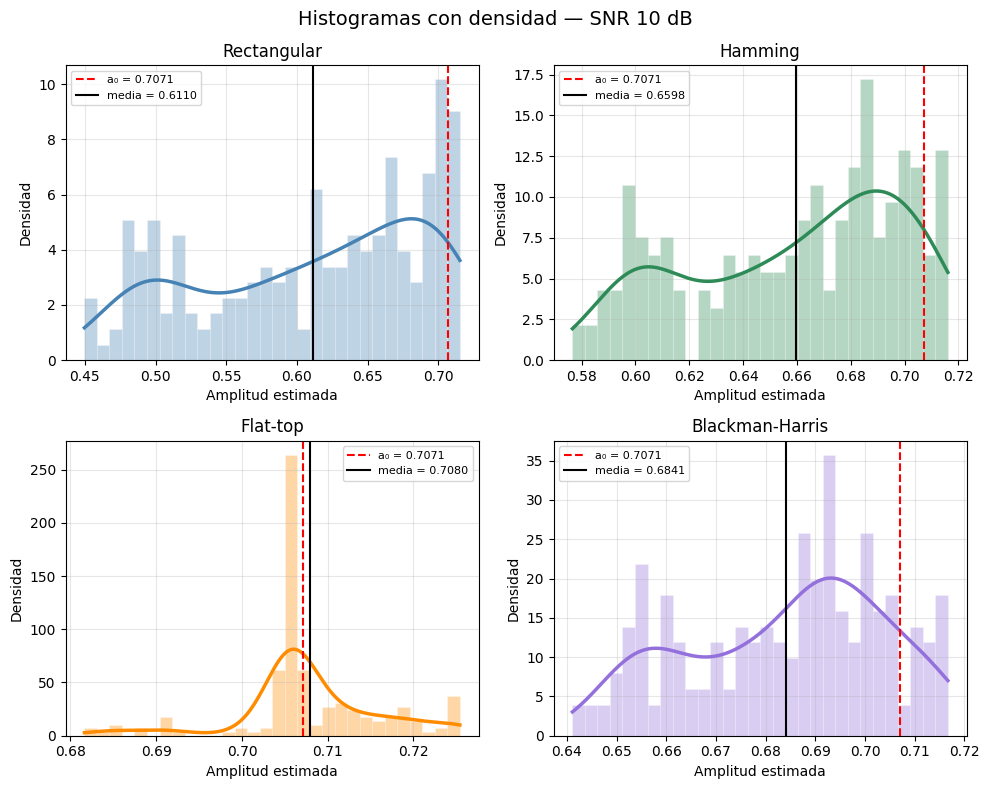

In [43]:

fig, axes = plt.subplots(2, 2, figsize=(10, 8))
fig.suptitle("Histogramas con densidad — SNR 10 dB", fontsize=14)

datos = [
    (a_rect,     'Rectangular',     'steelblue'),
    (a_hamming,  'Hamming',         'seagreen'),
    (a_flattop,  'Flat-top',        'darkorange'),
    (a_blackman, 'Blackman-Harris', 'mediumpurple'),
]

for ax, (a, nombre, color) in zip(axes.flat, datos):
    ax.hist(a, bins=30, color=color, alpha=0.35, edgecolor='white',
            linewidth=0.5, density=True)

    kde = gaussian_kde(a)
    x_kde = np.linspace(a.min(), a.max(), 300)
    ax.plot(x_kde, kde(x_kde), color=color, linewidth=2.5)

    ax.axvline(a0,         color='red',   linestyle='--', linewidth=1.5, label=f'a₀ = {a0:.4f}')
    ax.axvline(np.mean(a), color='black', linestyle='-',  linewidth=1.5, label=f'media = {np.mean(a):.4f}')

    ax.set_title(nombre)
    ax.set_xlabel("Amplitud estimada")
    ax.set_ylabel("Densidad")
    ax.legend(fontsize=8)
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

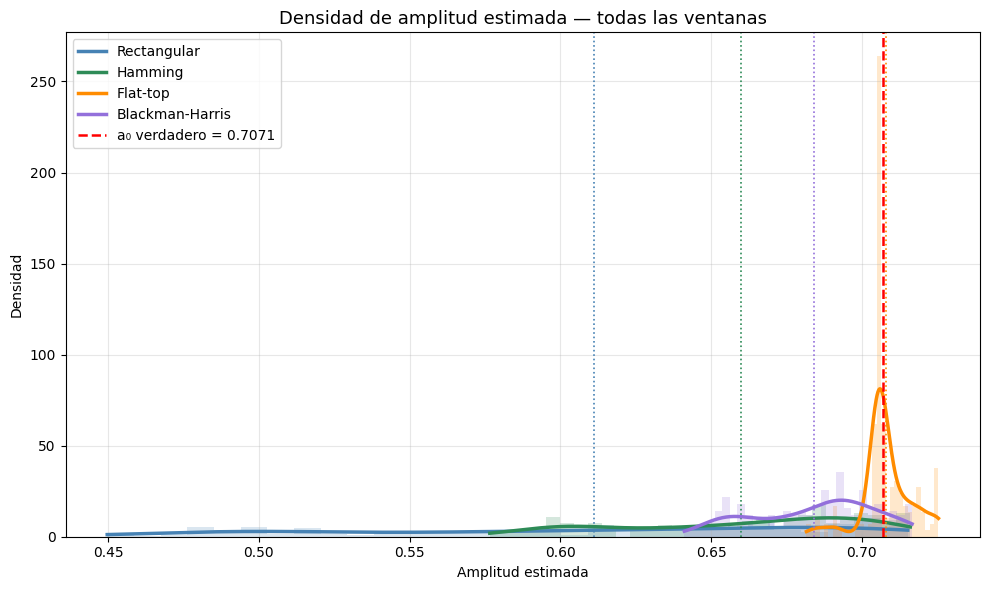

In [44]:
fig, ax = plt.subplots(figsize=(10, 6))
ax.set_title("Densidad de amplitud estimada — todas las ventanas", fontsize=13)

for a, nombre, color in datos:
    ax.hist(a, bins=30, color=color, alpha=0.2, edgecolor='none', density=True)

    kde = gaussian_kde(a)
    x_kde = np.linspace(a.min(), a.max(), 300)
    ax.plot(x_kde, kde(x_kde), color=color, linewidth=2.5, label=nombre)
    ax.axvline(np.mean(a), color=color, linestyle=':', linewidth=1.2)

ax.axvline(a0, color='red', linestyle='--', linewidth=1.8, label=f'a₀ verdadero = {a0:.4f}')

ax.set_xlabel("Amplitud estimada")
ax.set_ylabel("Densidad")
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [45]:

nombres       = ['Rectangular', 'Hamming', 'Flat-top', 'Blackman-Harris']
sesgos_amp     = [Sa_rect,            Sa_hamming,            Sa_flattop,            Sa_blackman]
sesgos_rel_amp = [sesgo_rel_amp_rect, sesgo_rel_amp_hamming, sesgo_rel_amp_flattop, sesgo_rel_amp_blackman]
varianzas_amp  = [var_rect,           var_hamming,           var_flattop,           var_blackman]
medias_amp     = [a_rect_mean,        a_hamming_mean,        a_flattop_mean,        a_blackman_mean]

print("=" * 82)
print(f"{'Ventana':<18} {'Sesgo':>14} {'Sesgo (%)':>11} {'Varianza':>14} {'Media':>14}")
print("=" * 82)
for n, s, sr, v, m in zip(nombres, sesgos_amp, sesgos_rel_amp, varianzas_amp, medias_amp):
    print(f"{n:<18} {s:>+14.6f} {sr:>+10.3f}% {v:>14.3e} {m:>14.6f}")
print("=" * 82)

Ventana                     Sesgo   Sesgo (%)       Varianza          Media
Rectangular             +0.096065    +13.586%      6.239e-03       0.611041
Hamming                 +0.047300     +6.689%      1.549e-03       0.659807
Flat-top                -0.000852     -0.120%      6.753e-05       0.707959
Blackman-Harris         +0.022983     +3.250%      3.931e-04       0.684124


#### Estimador de Amplitud 3dB

In [46]:
a0 = np.sqrt(2)/2
a_rect = np.max(np.abs(xdft3_rect[:,:N//2])/N, axis=1)
a_hamming = np.max(np.abs(xdft3_hamming[:,:N//2])/N, axis=1)
a_flattop = np.max(np.abs(xdft3_flattop[:,:N//2])/N, axis=1)
a_blackman = np.max(np.abs(xdft3_blackman[:,:N//2])/N, axis=1)
    
var_rect = np.var(a_rect) 
var_hamming = np.var(a_hamming) 
var_flattop = np.var(a_flattop) 
var_blackman = np.var(a_blackman) 

a_rect_mean = np.mean(a_rect)
a_hamming_mean = np.mean(a_hamming) 
a_flattop_mean = np.mean(a_flattop) 
a_blackman_mean = np.mean(a_blackman) 

Sa_rect =  a0 - a_rect_mean
Sa_hamming = a0 - a_hamming_mean 
Sa_flattop = a0 - a_flattop_mean
Sa_blackman = a0 - a_blackman_mean

sesgo_rel_amp_rect     = (Sa_rect     / a0) * 100
sesgo_rel_amp_hamming  = (Sa_hamming  / a0) * 100
sesgo_rel_amp_flattop  = (Sa_flattop  / a0) * 100
sesgo_rel_amp_blackman = (Sa_blackman / a0) * 100

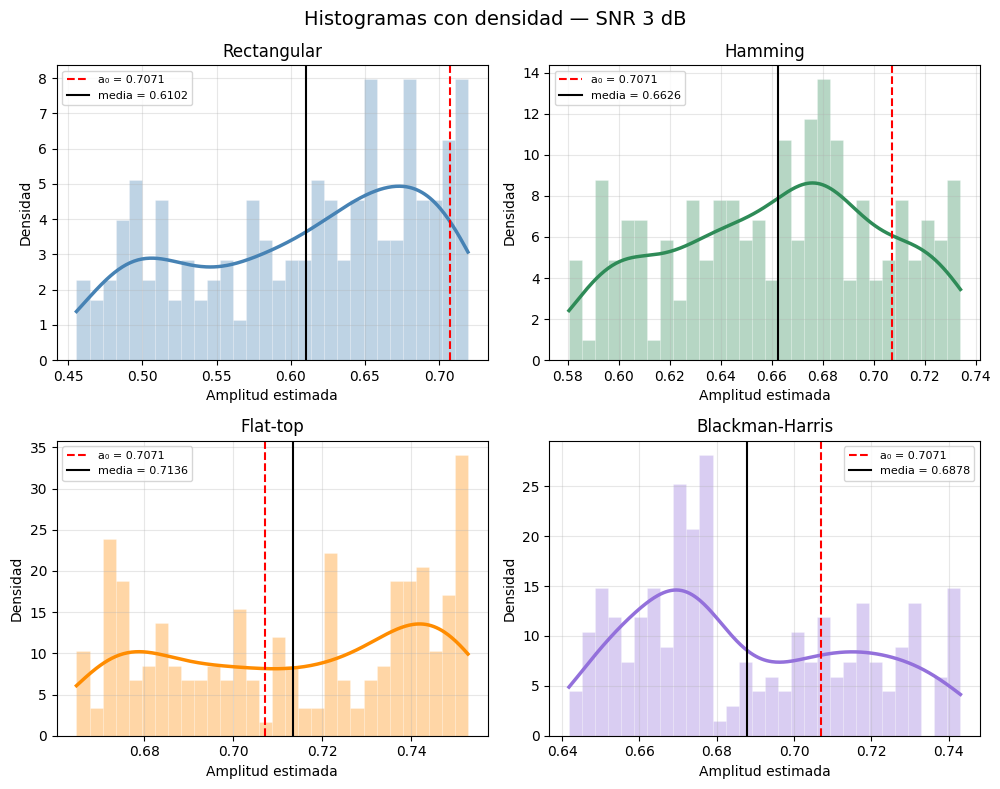

In [47]:

fig, axes = plt.subplots(2, 2, figsize=(10, 8))
fig.suptitle("Histogramas con densidad — SNR 3 dB", fontsize=14)

datos = [
    (a_rect,     'Rectangular',     'steelblue'),
    (a_hamming,  'Hamming',         'seagreen'),
    (a_flattop,  'Flat-top',        'darkorange'),
    (a_blackman, 'Blackman-Harris', 'mediumpurple'),
]

for ax, (a, nombre, color) in zip(axes.flat, datos):
    ax.hist(a, bins=30, color=color, alpha=0.35, edgecolor='white',
            linewidth=0.5, density=True)

    kde = gaussian_kde(a)
    x_kde = np.linspace(a.min(), a.max(), 300)
    ax.plot(x_kde, kde(x_kde), color=color, linewidth=2.5)

    ax.axvline(a0,         color='red',   linestyle='--', linewidth=1.5, label=f'a₀ = {a0:.4f}')
    ax.axvline(np.mean(a), color='black', linestyle='-',  linewidth=1.5, label=f'media = {np.mean(a):.4f}')

    ax.set_title(nombre)
    ax.set_xlabel("Amplitud estimada")
    ax.set_ylabel("Densidad")
    ax.legend(fontsize=8)
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

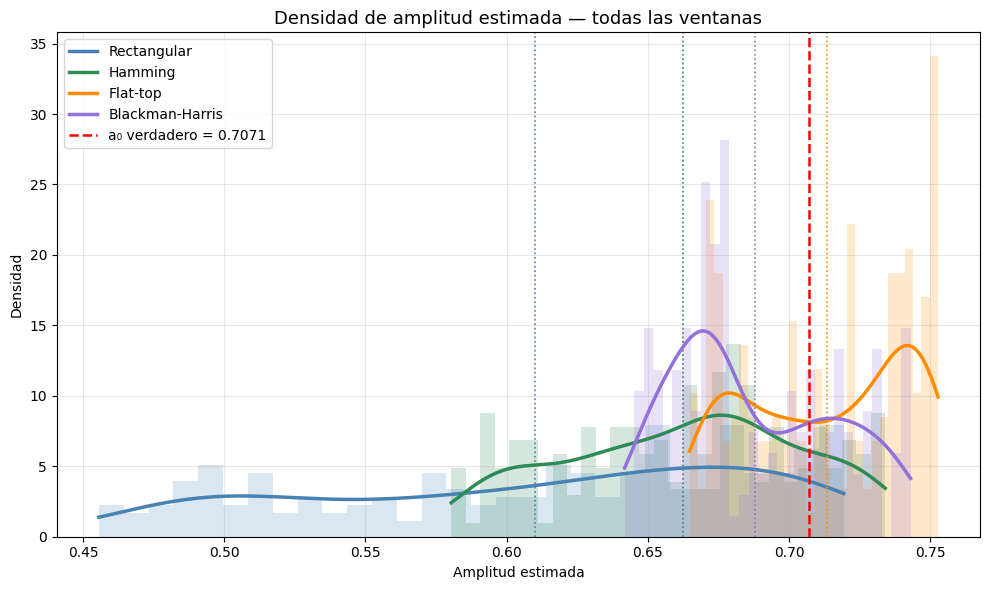

In [48]:
fig, ax = plt.subplots(figsize=(10, 6))
ax.set_title("Densidad de amplitud estimada — todas las ventanas", fontsize=13)

for a, nombre, color in datos:
    ax.hist(a, bins=30, color=color, alpha=0.2, edgecolor='none', density=True)

    kde = gaussian_kde(a)
    x_kde = np.linspace(a.min(), a.max(), 300)
    ax.plot(x_kde, kde(x_kde), color=color, linewidth=2.5, label=nombre)
    ax.axvline(np.mean(a), color=color, linestyle=':', linewidth=1.2)

ax.axvline(a0, color='red', linestyle='--', linewidth=1.8, label=f'a₀ verdadero = {a0:.4f}')

ax.set_xlabel("Amplitud estimada")
ax.set_ylabel("Densidad")
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [49]:

nombres   = ['Rectangular', 'Hamming', 'Flat-top', 'Blackman-Harris']
# Amplitud
sesgos_amp     = [Sa_rect,            Sa_hamming,            Sa_flattop,            Sa_blackman]
sesgos_rel_amp = [sesgo_rel_amp_rect, sesgo_rel_amp_hamming, sesgo_rel_amp_flattop, sesgo_rel_amp_blackman]
varianzas_amp  = [var_rect,           var_hamming,           var_flattop,           var_blackman]
medias_amp     = [a_rect_mean,        a_hamming_mean,        a_flattop_mean,        a_blackman_mean]

print("=" * 82)
print(f"{'Ventana':<18} {'Sesgo':>14} {'Sesgo (%)':>11} {'Varianza':>14} {'Media':>14}")
print("=" * 82)
for n, s, sr, v, m in zip(nombres, sesgos_amp, sesgos_rel_amp, varianzas_amp, medias_amp):
    print(f"{n:<18} {s:>+14.6f} {sr:>+10.3f}% {v:>14.3e} {m:>14.6f}")
print("=" * 82)


Ventana                     Sesgo   Sesgo (%)       Varianza          Media
Rectangular             +0.096902    +13.704%      6.084e-03       0.610205
Hamming                 +0.044547     +6.300%      1.752e-03       0.662560
Flat-top                -0.006462     -0.914%      8.155e-04       0.713569
Blackman-Harris         +0.019267     +2.725%      8.219e-04       0.687840


Se puede ver como para el caso de 10dB y de 3dB el estimador propuesto presenta un menor sesgo y Varianza.

Uso como estimador de frecuencia el index de la componente maxima pero laa comparo con np.pi/2 que es lo mismo que hacer la media de ff para obtener el sesgo, ya que son muchas realizaciones

#### Estimador de Frecuencia 10dB

In [50]:
index_rect     = np.argmax(np.abs(xdft10_rect[:,:N//2]), axis=1)
index_hamming  = np.argmax(np.abs(xdft10_hamming[:,:N//2]), axis=1)
index_flattop  = np.argmax(np.abs(xdft10_flattop[:,:N//2]), axis=1)
index_blackman = np.argmax(np.abs(xdft10_blackman[:,:N//2]), axis=1)

ff_rect     = np.mean(index_rect*deltaf)
ff_hamming  = np.mean(index_hamming*deltaf)
ff_flattop  = np.mean(index_flattop*deltaf)
ff_blackman = np.mean(index_blackman*deltaf)

var_ff_rect = np.var(index_rect*deltaf) 
var_ff_hamming = np.var(index_hamming*deltaf) 
var_ff_flattop = np.var(index_flattop*deltaf) 
var_ff_blackman = np.var(index_blackman*deltaf) 

sesgo_ff_rect     = np.pi/2 - ff_rect
sesgo_ff_hamming  = np.pi/2 - ff_hamming
sesgo_ff_flattop  = np.pi/2 - ff_flattop
sesgo_ff_blackman = np.pi/2 - ff_blackman


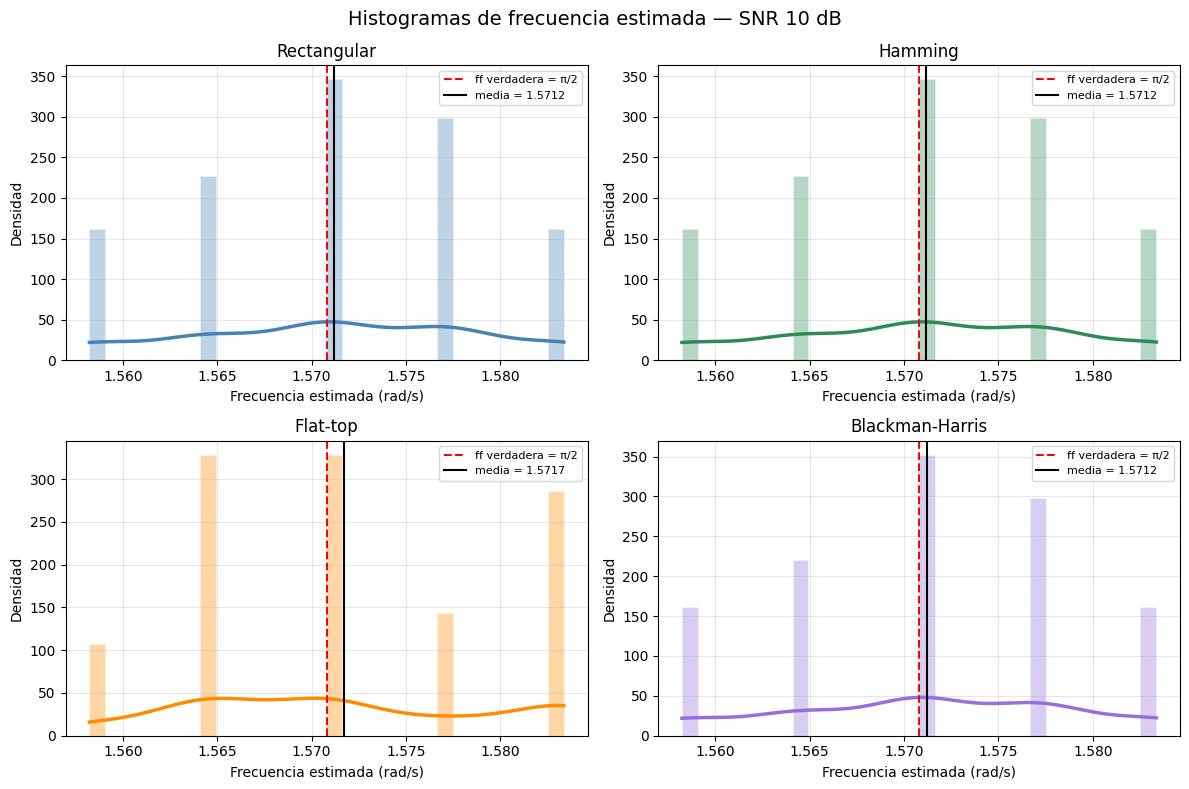

In [51]:
ff_estimadas = [
    (index_rect     * deltaf, 'Rectangular',     'steelblue'),
    (index_hamming  * deltaf, 'Hamming',         'seagreen'),
    (index_flattop  * deltaf, 'Flat-top',        'darkorange'),
    (index_blackman * deltaf, 'Blackman-Harris', 'mediumpurple'),
]

fig, axes = plt.subplots(2, 2, figsize=(12, 8))
fig.suptitle("Histogramas de frecuencia estimada — SNR 10 dB", fontsize=14)

for ax, (ff_est, nombre, color) in zip(axes.flat, ff_estimadas):
    ax.hist(ff_est, bins=30, color=color, alpha=0.35, edgecolor='white',
            linewidth=0.5, density=True)

    kde = gaussian_kde(ff_est)
    x_kde = np.linspace(ff_est.min(), ff_est.max(), 300)
    ax.plot(x_kde, kde(x_kde), color=color, linewidth=2.5)

    ax.axvline(np.pi/2,          color='red',   linestyle='--', linewidth=1.5, label=f'ff verdadera = π/2')
    ax.axvline(np.mean(ff_est),  color='black', linestyle='-',  linewidth=1.5, label=f'media = {np.mean(ff_est):.4f}')

    ax.set_title(nombre)
    ax.set_xlabel("Frecuencia estimada (rad/s)")
    ax.set_ylabel("Densidad")
    ax.legend(fontsize=8)
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [52]:
nombres       = ['Rectangular', 'Hamming', 'Flat-top', 'Blackman-Harris']
sesgos_ff     = [sesgo_ff_rect,   sesgo_ff_hamming,   sesgo_ff_flattop,   sesgo_ff_blackman]
varianzas_ff  = [var_ff_rect,     var_ff_hamming,     var_ff_flattop,     var_ff_blackman]
medias_ff     = [ff_rect,         ff_hamming,         ff_flattop,         ff_blackman]

print("=" * 82)
print(f"{'Ventana':<18} {'Sesgo':>14} {'Varianza':>14} {'Media':>14}")
print("=" * 82)
for n, s, v, m in zip(nombres, sesgos_ff, varianzas_ff, medias_ff):
    print(f"{n:<18} {s:>+14.8f} {v:>14.4e} {m:>14.8f}")
print("=" * 82)

Ventana                     Sesgo       Varianza          Media
Rectangular           -0.00037699     5.9865e-05     1.57117332
Hamming               -0.00037699     5.9865e-05     1.57117332
Flat-top              -0.00091106     6.6875e-05     1.57170739
Blackman-Harris       -0.00040841     5.9643e-05     1.57120473


#### Estimador de Frecuencia 3dB

In [53]:
index_rect     = np.argmax(np.abs(xdft3_rect[:,:N//2]), axis=1)
index_hamming  = np.argmax(np.abs(xdft3_hamming[:,:N//2]), axis=1)
index_flattop  = np.argmax(np.abs(xdft3_flattop[:,:N//2]), axis=1)
index_blackman = np.argmax(np.abs(xdft3_blackman[:,:N//2]), axis=1)

ff_rect     = np.mean(index_rect*deltaf)
ff_hamming  = np.mean(index_hamming*deltaf)
ff_flattop  = np.mean(index_flattop*deltaf)
ff_blackman = np.mean(index_blackman*deltaf)

var_ff_rect = np.var(index_rect*deltaf) 
var_ff_hamming = np.var(index_hamming*deltaf) 
var_ff_flattop = np.var(index_flattop*deltaf) 
var_ff_blackman = np.var(index_blackman*deltaf) 

sesgo_ff_rect     = np.pi/2 - ff_rect
sesgo_ff_hamming  = np.pi/2 - ff_hamming
sesgo_ff_flattop  = np.pi/2 - ff_flattop
sesgo_ff_blackman = np.pi/2 - ff_blackman


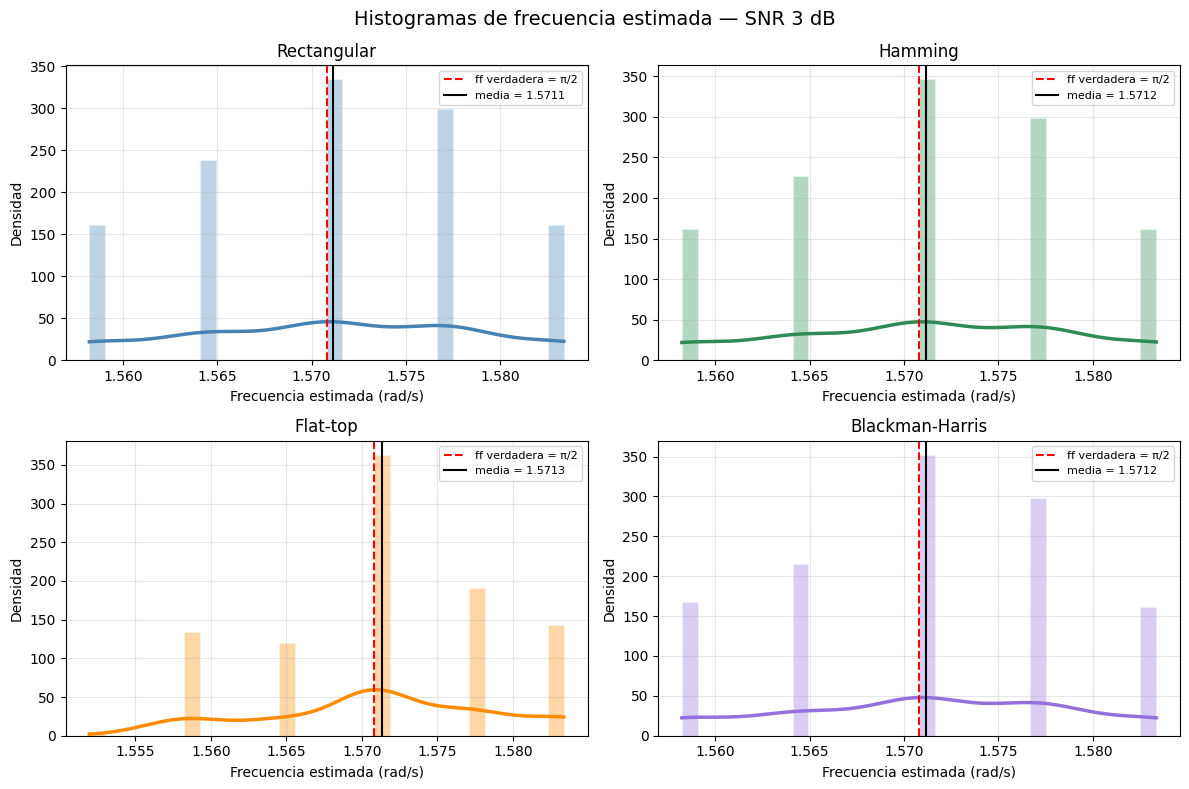

In [54]:
ff_estimadas = [
    (index_rect     * deltaf, 'Rectangular',     'steelblue'),
    (index_hamming  * deltaf, 'Hamming',         'seagreen'),
    (index_flattop  * deltaf, 'Flat-top',        'darkorange'),
    (index_blackman * deltaf, 'Blackman-Harris', 'mediumpurple'),
]

fig, axes = plt.subplots(2, 2, figsize=(12, 8))
fig.suptitle("Histogramas de frecuencia estimada — SNR 3 dB", fontsize=14)

for ax, (ff_est, nombre, color) in zip(axes.flat, ff_estimadas):
    ax.hist(ff_est, bins=30, color=color, alpha=0.35, edgecolor='white',
            linewidth=0.5, density=True)

    kde = gaussian_kde(ff_est)
    x_kde = np.linspace(ff_est.min(), ff_est.max(), 300)
    ax.plot(x_kde, kde(x_kde), color=color, linewidth=2.5)

    ax.axvline(np.pi/2,          color='red',   linestyle='--', linewidth=1.5, label=f'ff verdadera = π/2')
    ax.axvline(np.mean(ff_est),  color='black', linestyle='-',  linewidth=1.5, label=f'media = {np.mean(ff_est):.4f}')

    ax.set_title(nombre)
    ax.set_xlabel("Frecuencia estimada (rad/s)")
    ax.set_ylabel("Densidad")
    ax.legend(fontsize=8)
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [55]:
nombres       = ['Rectangular', 'Hamming', 'Flat-top', 'Blackman-Harris']
sesgos_ff     = [sesgo_ff_rect,   sesgo_ff_hamming,   sesgo_ff_flattop,   sesgo_ff_blackman]
varianzas_ff  = [var_ff_rect,     var_ff_hamming,     var_ff_flattop,     var_ff_blackman]
medias_ff     = [ff_rect,         ff_hamming,         ff_flattop,         ff_blackman]

print("=" * 82)
print(f"{'Ventana':<18} {'Sesgo':>14} {'Varianza':>14} {'Media':>14}")
print("=" * 82)
for n, s, v, m in zip(nombres, sesgos_ff, varianzas_ff, medias_ff):
    print(f"{n:<18} {s:>+14.8f} {v:>14.4e} {m:>14.8f}")
print("=" * 82)

Ventana                     Sesgo       Varianza          Media
Rectangular           -0.00031416     6.0303e-05     1.57111049
Hamming               -0.00037699     5.9865e-05     1.57117332
Flat-top              -0.00050265     6.0149e-05     1.57129898
Blackman-Harris       -0.00037699     6.0260e-05     1.57117332
